<a href="https://colab.research.google.com/github/luciestrada/Proyecto2_Biosenales_LucianaAcevedo_LucianaEstrada/blob/main/Proyecto2_biosenales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consulta**

**Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en
densidad espectral de potencia, mejoran la clasificación de estados en BCI. Citar las fuentes**

**Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar
librerías, explicar la medida y su uso en los datos del proyecto**

En el proyecto 1 utilizamos la densidad espectral de potencia (PSD) calculado con el método de Welch.

1.   **Varianza logarítmica CSP (Patrones Espaciles Comunes)**
Es una técnica de extracción de características ampliamente utilizada en problemas de clasificiación binaria, utiliza un filtrado espacial que transforma señales muticanal de EEG proyectándolas en una matriz de pesos óptimos. El funcionamiento matemático se basa en maximizar la varianza de la señal filtrada para una clase (por ejemplo la imaginación del movimiento de la mano derecha), mientras minimiza la varianza para la otra clase (mano izquierda). Una vez aplicados los filtros espaciales, se calcula la varianza de estas nuevas señales proyectadas y se le aplica una transformación logarítmica (Ramoser et al., 2000).

En otras palabras al aplicar CSP sobre los canales de interés de la corteza motora, el algoritmo aisla matemáticamente las fuentes subyacentes a los electrodos $C3$, $Cz$ y $C4$. Esto incrementa la distancia geométrica entre las clases en el espacio de características, facilitando la tarea del clasificador.

Para cosntruir las caracteríticas Log-Varianza, se calcula la varianza de cada señal z, se normaliza por la varianza total de todas las señales, y se aplica una transformada logarítimca.

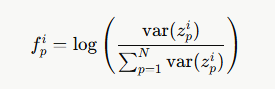




```
Libreria: mne.decoding
```
```

from mne.decoding import CSP
import numpy as np

# Suponiendo que 'epochs_data' tiene la forma (trials, canales, muestras)
# y 'labels' contiene las etiquetas de las clases (0 o 1)
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Entrena los filtros espaciales y extrae la varianza logarítmica de forma automática
X_csp = csp.fit_transform(epochs_data, labels)
# X_csp tendrá una dimensión de (trials, 4), listo para el clasificador
```

El vector de características final se construye  combinando las log-varianzas de todas las señales.




2. **Parámetros de Hjorth (dominio temporal)**

Son descriptores temporales calculados directamente sobre la señal sin transformada de Fourier, es decir,  aplicados directamente en el dominio del tiempo sobre señales univariadas (canal por canal).  Se basan en los momentos de la densidad espectral de potencia, calculados a través de la varianza de la señal original y sus derivadas sucesivas.

- **Actividad** = Representa la  varianza de de la amplitud de la señal(potencia).

$$\text{Actividad} = \sigma_x^2 = \text{Var}(x(t))$$

- **Movilidad**= Proporciona una estimación de la frecuencia media de la señal. Es la raíz de la varianza de la primera derivada dividida por la varianza de la señal.

$$\text{Movilidad} = \sqrt{\frac{\text{Var}(x'(t))}{\text{Var}(x(t))}}$$

- **Complejidad** = Indica qué tan similar es la señal a una onda senoidal pura. Es la movilidad de la derivada dividida por la movilidad de la señal.


$$\text{Complejidad} = \frac{\text{Movilidad}(x'(t))}{\text{Movilidad}(x(t))} = \sqrt{\frac{\text{Var}(x''(t))/\text{Var}(x'(t))}{\text{Var}(x'(t))/\text{Var}(x(t))}}$$



Durante el estado de reposo, las señales de la corteza motora muestran ondas rítmicas, suaves y sincronizadas (ritmo Mu/Alfa), lo que se traduce en una baja Movilidad y una Complejidad cercana a 1.  En BCI de MI, la complejidad tiende a ser mayor durante la imaginación que durante el movimiento real, , ya que el primero genera una señal más regular por retroalimentación propioceptiva.


```
Libreria: antropy o mne_features.univariate
```
```
import antropy as am
import numpy as np

# Se calcula sobre una matriz 'signal_epoch' de dimensiones (n_channels, n_times)
hjorth_features = []
for channel_data in signal_epoch:
    mobility, complexity = am.hjorth_params(channel_data)
    hjorth_features.extend([mobility, complexity])
# Retorna un vector con los índices de movilidad y complejidad por canal
```
Los parámetros de Hjorth capturan esta transición geométrica instantáneamente en cada época de análisis.  (Hjorth, 1970)

3. **Entropía de Permutación (PE)**

Es una métrica basada en la dinámica no lineal y la teoría de la información que cuantifica la complejidad, el desorden y la impredecibilidad de una serie temporal compleja. Su principal ventaja es que evalúa las relaciones ordinales entre los puntos de la señal, ignorando las amplitudes absolutas del voltaje. Específicamente, la PE mide la regularidad de la señal comparando el orden relativo de sus valores en ventanas deslizantes de longitud $m$ (orden de embedding). Tras determinar el patrón ordinal (permutación) de cada ventana, se calcula la entropía de Shannon de la distribución de dichos patrones mediante la ecuación:


$$PE = -\sum p(\pi) \cdot \log(p(\pi))$$

donde $\pi$ recorre las $m!$ permutaciones posibles. De este modo, una señal completamente regular (como una sinusoide perfecta) exhibe un $PE \approx 0$, mientras que una señal totalmente aleatoria alcanza la PE máxima (Bandt & Pompe, 2002)


Durante tareas de Imaginería Motora (MI), la desincronización cortical incrementa la irregularidad de la señal, elevando consecuentemente la PE.

La Entropía de Permutación actúa como una alternativa radical a la PSD porque es completamente inmune a los artefactos de parpadeo ocular (EOG) de gran amplitud o cambios repentinos de impedancia. Al evaluar las épocas del dataset, la PE cuantificará con alta precisión el incremento del caos combinatorio microestructural de la señal, provocado por la fragmentación del ritmo de reposo durante la activación motora (tanto imaginada como real). *De hecho, la literatura demuestra que la PE discrimina estados de reposo, MI y MR de mejor manera que la PSD en sujetos con baja relación señal-ruido (SNR) (Li et al., 2014)*.




```
Librería: antropy
```
```
import antropy as am

# Se recomienda fijar el orden (dimension) d=3, 4 o 5 y el delay delay=1
# signal_channel es un arreglo unidimensional (n_times,)
perm_entropy = am.permutation_entropy(signal_channel, order=3, delay=1, normalize=True)
```


En el contexto de los datos del proyecto, se aplica CSP de manera binaria por pares de condiciones: MR-D vs MR-I, y IM-D vs IM-I, utilizando los 6 canales seleccionados (C3, C4, FC3, FC4, CP3, CP4). Se seleccionan los primeros y últimos 3 componentes del vector propio (m=3, es decir 6 filtros espaciales), tal como recomienda la literatura. La log-varianza de estos componentes constituye el vector de características que se almacena en el dataframe junto con las métricas del proyecto 1.

**Implementación en Python:** Se puede implementar directamente utilizando la librería especializada en neurotecnología MNE-Python (mne.decoding.CSP) en combinación con scikit-learn.

# **Plan de análisis**

**Con la información recolectada, del entregable 1 y del punto anterior, proponer una
metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados
a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda**



**Etapa 1: Carga y Preprocesamiento de los Datos**
La primera etapa corresponde a la carga y acondicionamiento de las señales bioeléctricas.
El pipeline de preprocesamiento es idéntico al implementado en el Proyecto 1 :

- Filtro Notch: Aplicado a 60 Hz para eliminar la interferencia de la red eléctrica.
- Filtro Pasa-Altas: A 1 Hz para remover la deriva de la línea base y frecuencias ultrabajas.
- Filtro Pasa-Bajas: A 40 Hz para limitar el ancho de banda a las frecuencias de interés cognitivo y descartar ruido muscular de alta frecuencia.
- Re-referenciación: Aplicación de Promedio Común (CAR) para reducir el ruido global de los electrodos y mejorar la Relación Señal-Ruido (SNR).
- Segmentación (Epoching): Extracción de épocas desde −1.0 hasta 4.5 segundos respecto al evento motor (pista visual en $t=0$), fijando la corrección de línea base (baseline) entre −1.0 y 0 segundos. Este procedimiento garantiza que las señales estén limpias y normalizadas antes de extraer características.

----

**Etapa 2: Extracción de Características Multidimensionales**

Se implementará una función unificada extraer_caracteristicas(epochs, canales) que calculará, para cada época y cada canal de interés de la corteza motora primaria (C3, C4, FC3, FC4, CP3, CP4), un conjunto de índices complementarios que cubren cuatro dimensiones independientes de la señal EEG:

- Dimensión Frecuencial (Proyecto 1): Se calcula la Densidad Espectral de Potencia (PSD) por bandas Mu (8–13 Hz) y Beta (13–30 Hz) mediante el método de Welch, el porcentaje de desincronización relacionada con el evento (ERD%), y el índice de lateralidad (LI) -
- Dimensión Espacial (Varianza Logarítmica CSP): Se aplica el algoritmo de Patrones Espaciales Comunes (CSP) de forma binaria directa para maximizar la diferencia entre las dos tareas activas (IM-D vs IM-I), seleccionando $m=3$ filtros extremos del vector propio (6 filtros espaciales en total). La log-varianza de las señales proyectadas constituye el vector de características espaciales, y las épocas de reposo se proyectan sobre este mismo espacio para evaluar su comportamiento basal
- Dimensión Temporal (Parámetros de Hjorth): Se calculan los tres descriptores de Hjorth —actividad, movilidad y complejidad—. Para evitar que la señal pierda poder discriminativo, estos parámetros se calcularán sobre la señal en banda ancha preprocesada (1–40 Hz), capturando los cambios geométricos rápidos inducidos por la desincronización neuronal de manera robusta ante la variabilidad inter-sujeto (Hjorth, 1970).
- Dimensión de Complejidad Dinámica: Se calcula la Entropía de Permutación (PE) con orden $m=4$ (longitud que cumple con la condición de estabilidad $N \gg m!$) y retraso $lag=1$ mediante la librería antropy. La PE cuantifica el grado de desorden en la microestructura temporal de la señal sin asumir estacionariedad, siendo ideal para épocas cortas (Bandt & Pompe, 2002).
----

**Etapa 3: Construcción del Dataframe Unificado**

Una rutina de procesamiento por lotes aplicará la función de extracción sobre todos los archivos de todos los sujetos del dataset. Los resultados se estructurarán y consolidarán en un único DataFrame con las columnas: Sujeto, Condicion (REST, IM-D, IM-I), Canal, Banda, Indice y Valor, permitiendo segmentar y consultar cualquier combinación de variables de forma directa.

---

**Etapa 4: Análisis Descriptivo y Estadístico Inferencial**

Para la visualización de datos se emplearán diagramas de caja (boxplots) y gráficos de violín (violinplots) para comparar las distribuciones entre las tres condiciones, junto con mapas de calor de p-valores para identificar los contrastes estadísticamente relevantes .
Dado que el diseño experimental es de medidas repetidas (los mismos sujetos participan en todas las tareas, generando datos correlacionados ), la selección de la prueba estadística inferencial seguirá un criterio estricto de distribución:

- Se aplicará la prueba de Shapiro-Wilk a cada variable para evaluar la normalidad.
- Si se rechaza la hipótesis de normalidad ($p < 0.05$), se utilizará la Prueba de Friedman (equivalente **no paramétrico** para medidas repetidas) para comparar las 3 condiciones, seguida de comparaciones post-hoc por pares mediante la Prueba de Rangos con Signos de Wilcoxon para muestras relacionadas, aplicando la corrección de Bonferroni ($\alpha_{\text{ajustado}} = 0.05 / 3 = 0.0166$).
- Si los datos no rechazan la normalidad, se empleará un ANOVA de Medidas Repetidas con la prueba post-hoc de Tukey.

---

**Etapa 5: Selección de Características (Feature Selection)**


**Etapa 6: Clasificación y Evaluación de Modelos**



# **Planteamiento de Hipótesis**

1. **Dimensión de Frecuencia (PSD en Banda μ)**

- $H_0$: No existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante las IM-D.

- $H_1$: Existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante IM-D.

*Existen diferencias significativas en la potencia de la banda Mu entre C3 y C4 durante IM-D, reflejando el control contralateral esperado.*

2. **Dimensión Temporal (Movilidad de Hjorth)**

- $H_0$: No existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.
- $H_2$: Existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.

*La Movilidad de Hjorth en C3 es significativamente diferente durante IM-D respecto a REST, evidenciando activación del hemisferio contralateral*

3. **Dimensión No-Lineal (Entropía de Permutación)**
- $H_0$: No existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).
- $H_3$: Existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).

*Evaluar la Entropía de Permutación en C4 durante la condición de mano izquierda permite ver si el caos de la señal cambia en el lugar correcto del cerebro.*

*La Entropía de Permutación en C4 es significativamente diferente durante IM-I respecto a REST, reflejando mayor complejidad dinámica en el hemisferio contralateral a la mano imaginada*

4. **Dimensión Espacial (Filtro CSP)**
- $H_0$: No existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.
- $H_4$: Existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.

*La log-varianza del primer componente CSP difiere significativamente entre IM-D e IM-I, demostrando que el filtro espacial separa ambas condiciones de lateralidad*

5. **Dimensión de Clasificación (Rendimiento BCI)**
- $H_0$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es igual o menor al nivel de azar teórico del 33.3%.
- $H_5$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es significativamente superior al nivel de azar teórico del 33.3%.




# CÓDIGO

In [ ]:
!pip install openneuro-py mne-bids

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 30.0 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
!pip install -q mne antropy

In [ ]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mne
import antropy as ant

from google.colab import drive
from scipy import signal as sci_signal
from scipy.signal import sosfiltfilt, butter
from scipy.integrate import trapezoid
from scipy import stats
from mne.decoding import CSP


In [ ]:
drive.mount('/content/drive')

RUTA_DRIVE = '/content/drive/MyDrive/Proyecto_BCI_2026'
os.makedirs(RUTA_DRIVE, exist_ok=True)

SUJETOS = [f'sub-{str(i).zfill(3)}' for i in range(1, 21)] # 20 sujetos
RUNS_DESCARGAR = range(1, 9)
EXTENSIONES    = ['_eeg.set', '_events.tsv', '_channels.tsv', '_eeg.json']
BASE_URL       = "https://openneuro.org/crn/datasets/ds004362/files"

def descargar_archivo(url, destino):
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return "ya existe"
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    try:
        urllib.request.urlretrieve(url, destino)
        return "ok"
    except Exception as e:
        return f"error: {e}"

print("Descargando datos...\n")
for sub in SUJETOS:
    print(f"  {sub}...")
    for run in RUNS_DESCARGAR:
        for ext in EXTENSIONES:
            nombre  = f"{sub}_task-motion_run-{run}{ext}"
            url     = f"{BASE_URL}/{sub}:eeg:{nombre}"
            destino = os.path.join(RUTA_DRIVE, sub, 'eeg', nombre)
            estado  = descargar_archivo(url, destino)
            if estado not in ("ya existe", "ok"):
                print(f"    {nombre}: {estado}")
    sets = [f for f in os.listdir(os.path.join(RUTA_DRIVE, sub, 'eeg'))
            if f.endswith('.set')]
    print(f"    {len(sets)} archivos .set")

print("\nDescarga completa.")

Mounted at /content/drive
Descargando datos...

  sub-001...
    14 archivos .set
  sub-002...
    14 archivos .set
  sub-003...
    14 archivos .set
  sub-004...
    14 archivos .set
  sub-005...
    14 archivos .set
  sub-006...
    8 archivos .set
  sub-007...
    8 archivos .set
  sub-008...
    8 archivos .set
  sub-009...
    8 archivos .set
  sub-010...
    8 archivos .set
  sub-011...
    8 archivos .set
  sub-012...
    8 archivos .set
  sub-013...
    8 archivos .set
  sub-014...
    8 archivos .set
  sub-015...
    8 archivos .set
  sub-016...
    8 archivos .set
  sub-017...
    8 archivos .set
  sub-018...
    8 archivos .set
  sub-019...
    8 archivos .set
  sub-020...
    8 archivos .set

Descarga completa.


Carga de archivos

In [ ]:
RUNS_INTERES    = [3, 4, 7, 8]
CANALES_INTERES = ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4']

datos = {}

for sub in SUJETOS:
    print(f"\nCargando {sub}...")
    datos[sub] = {}

    for run_num in RUNS_INTERES:
        ruta_set = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_eeg.set")
        ruta_ev  = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_events.tsv")

        if not os.path.exists(ruta_set):
            print(f"  run-{run_num}: no encontrado")
            continue

        raw = mne.io.read_raw_eeglab(ruta_set, preload=True, verbose=False)
        disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]
        raw.pick(disponibles)
        df_ev = pd.read_csv(ruta_ev, sep='\t')

        datos[sub][run_num] = {'raw': raw, 'events': df_ev}
        print(f"  run-{run_num}: OK | canales: {raw.ch_names} | eventos: {len(df_ev)}")

print("\nCarga completa.")


Cargando sub-001...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-002...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-003...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK |

Preprocesamiento (idéntico al Proyecto 1)

In [ ]:
def preprocesar_raw(raw):
    raw = raw.copy()
    raw.filter(l_freq=1.0, h_freq=None, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.filter(l_freq=None, h_freq=40.0, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.notch_filter(freqs=60.0, method='iir',
                     iir_params=dict(order=2, ftype='butter'),
                     verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    return raw

for sub in SUJETOS:
    for run_num in datos[sub]:
        datos[sub][run_num]['raw'] = preprocesar_raw(datos[sub][run_num]['raw'])
    print(f"{sub}: preprocesado")

print("\nPreprocesamiento completo.")

sub-001: preprocesado
sub-002: preprocesado
sub-003: preprocesado
sub-004: preprocesado
sub-005: preprocesado
sub-006: preprocesado
sub-007: preprocesado
sub-008: preprocesado
sub-009: preprocesado
sub-010: preprocesado
sub-011: preprocesado
sub-012: preprocesado
sub-013: preprocesado
sub-014: preprocesado
sub-015: preprocesado
sub-016: preprocesado
sub-017: preprocesado
sub-018: preprocesado
sub-019: preprocesado
sub-020: preprocesado

Preprocesamiento completo.


Segmentación en épocas (idéntico al Proyecto 1)

In [ ]:
T_MIN, T_MAX = -1.0, 4.5
BASELINE     = (-1.0, 0.0)

# Solo IM-D , IM-I Y Reposo( REST)
EVENTOS = {
    'TASK2T2': ('IM-D', 1),
    'TASK2T1': ('IM-I', 2),
    'TASK2T0': ('REST', 3),
    'TASK1T0': ('REST', 3),   # reposo de los runs de MR también sirve
}

CONDS_P2 = ['IM-D', 'IM-I', 'REST']

def segmentar_run(raw, df_events):
    sfreq = raw.info['sfreq']
    df_events['value'] = df_events['value'].astype(str).str.strip()
    df_filt = df_events[df_events['value'].isin(EVENTOS)].copy()
    if df_filt.empty:
        return {}
    samples  = (df_filt['onset'].values * sfreq).astype(int)
    ev_ids   = np.array([EVENTOS[v][1] for v in df_filt['value']])
    ev_array = np.column_stack([samples, np.zeros(len(samples), int), ev_ids])
    ev_dict  = {EVENTOS[v][0]: EVENTOS[v][1] for v in df_filt['value'].unique()}
    epochs   = mne.Epochs(raw, ev_array, event_id=ev_dict,
                          tmin=T_MIN, tmax=T_MAX, baseline=BASELINE,
                          reject=None, preload=True, verbose=False)
    return {cond: epochs[cond] for cond in ev_dict
            if cond in epochs.event_id and len(epochs[cond]) > 0}

epocas = {}
for sub in SUJETOS:
    print(f"\nSegmentando {sub}...")
    acumulado = {c: [] for c in CONDS_P2}
    for run_num, contenido in datos[sub].items():
        for cond, ep in segmentar_run(contenido['raw'], contenido['events']).items():
            if cond in acumulado:
                acumulado[cond].append(ep)
    epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
                   for c, l in acumulado.items()}
    for cond, ep in epocas[sub].items():
        n = len(ep) if ep is not None else 0
        print(f"  {cond}: {n} épocas")

print("\nSegmentación completa.")


Segmentando sub-001...
  IM-D: 14 épocas
  IM-I: 16 épocas
  REST: 56 épocas

Segmentando sub-002...


/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations withi

  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-003...
  IM-D: 15 épocas
  IM-I: 15 épocas
  REST: 56 épocas

Segmentando sub-004...


/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations withi

  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-005...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-006...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-007...


...

/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None


  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-015...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-016...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-017...


/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations withi

  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-018...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-019...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-020...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentación completa.


/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_2473/2828833460.py:38: RuntimeWarning: Concatenation of Annotations withi

Funciones de los índices nuevo

In [ ]:

def butter_bandpass(sfreq, fmin, fmax, order=4):
    nyq  = sfreq / 2.0
    low  = max(fmin / nyq, 1e-4)
    high = min(fmax / nyq, 1 - 1e-4)
    return butter(order, [low, high], btype='band', output='sos')

#Actividad, movilidad y complejidad de Hjorth para señal 1D.
def hjorth(signal):
    var_sig = np.var(signal)
    if var_sig == 0:
        return 0.0, 0.0, 0.0
    d1     = np.diff(signal)
    var_d1 = np.var(d1)
    mob    = np.sqrt(var_d1 / var_sig)
    d2     = np.diff(d1)
    var_d2 = np.var(d2)
    mob_d1 = np.sqrt(var_d2 / var_d1) if var_d1 > 0 else 0.0
    comp   = mob_d1 / mob if mob > 0 else 0.0
    return float(var_sig), float(mob), float(comp)

#Entropía de permutación normalizada.
def perm_entropy(signal, order=4, lag=1):
    try:
        return float(ant.perm_entropy(signal, order=order,
                                       delay=lag, normalize=True))
    except Exception:
        return np.nan


print("Funciones de índices nuevos definidas.")

Funciones de índices nuevos definidas.


Función de extracción completa (PSD del proyecto 1 + índices nuevos)

In [ ]:
# ============================================================
# BANDAS Y VENTANAS
# H1: psd_mu en C3 y C4
# H2: hjorth_mob en C3
# H3: pe_mu en C4
# H4: CSP_1..6 (se calcula aparte)
# H5: clasificación usa todo lo anterior + erd_mu + LI_mu
# ============================================================

T_BASELINE = (-1.0, 0.0)
T_ACTIVO   = (0.5,  3.5)

#Potencia en banda mu o beta por Welch
def pot_banda(data_1d, fmin, fmax, sfreq):
    n        = len(data_1d)
    nperseg  = min(256, n)
    noverlap = min(128, nperseg // 2)
    freqs, psd = sci_signal.welch(data_1d, fs=sfreq,
                                   nperseg=nperseg, noverlap=noverlap)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[idx], x=freqs[idx])


def calcular_metricas(epoch_data, times, sfreq, ch_names):
    """
    Dimensión frecuencial (Como en el proyecto 1):
        psd_mu_C3, psd_mu_C4       → H1
        erd_mu_C3, erd_mu_C4       → clasificación H5
        LI_mu                      → clasificación H5

    Dimensión temporal :
        hjorth_mob_C3, hjorth_mob_C4   → H2 + clasificación H5
        hjorth_comp_C3, hjorth_comp_C4 → clasificación H5

    Dimensión no lineal :
        pe_mu_C3, pe_mu_C4         → H3 + clasificación H5

    """

    def seg(t_ini, t_fin):
        idx = (times >= t_ini) & (times <= t_fin)
        return epoch_data[:, idx]

    seg_base = seg(*T_BASELINE)
    seg_act  = seg(*T_ACTIVO)

    m = {}

    # Solo C3 y C4
    for canal in ['C3', 'C4']:
        if canal not in ch_names:
            continue
        i = ch_names.index(canal)

        # PSD mu (H1)
        p_mu_base = pot_banda(seg_base[i], 8, 13, sfreq)
        p_mu_act  = pot_banda(seg_act[i],  8, 13, sfreq)
        m[f'psd_mu_{canal}'] = p_mu_act

        # ERD% mu (contexto P1 + clasificación H5)
        m[f'erd_mu_{canal}'] = ((p_mu_act - p_mu_base)
                                 / (p_mu_base + 1e-12)) * 100

        # Hjorth movilidad y complejidad (H2 + clasificación H5)
        sig = seg_act[i]
        _, mob, comp = hjorth(sig)
        m[f'hjorth_mob_{canal}']  = mob
        m[f'hjorth_comp_{canal}'] = comp

        # PE banda mu (H3 + clasificación H5)
        sos      = butter_bandpass(sfreq, 8, 13)
        sig_mu   = sosfiltfilt(sos, sig)
        m[f'pe_mu_{canal}'] = perm_entropy(sig_mu, order=4, lag=1)

    # ── LI mu (clasificación H5) ─────────────────────────────
    if 'C3' in ch_names and 'C4' in ch_names:
        p3 = pot_banda(seg_act[ch_names.index('C3')], 8, 13, sfreq)
        p4 = pot_banda(seg_act[ch_names.index('C4')], 8, 13, sfreq)
        m['LI_mu'] = (p3 - p4) / (p3 + p4 + 1e-12)

    return m

print("Columnas que genera por época:")
cols_esperadas = [
    'psd_mu_C3','psd_mu_C4',
    'erd_mu_C3','erd_mu_C4',
    'hjorth_mob_C3','hjorth_mob_C4',
    'hjorth_comp_C3','hjorth_comp_C4',
    'pe_mu_C3','pe_mu_C4',
    'LI_mu'
]
for c in cols_esperadas:
    print(f"  {c}")
print(f"Total: {len(cols_esperadas)} columnas de métricas + sujeto, condicion, trial")

Columnas que genera por época:
  psd_mu_C3
  psd_mu_C4
  erd_mu_C3
  erd_mu_C4
  hjorth_mob_C3
  hjorth_mob_C4
  hjorth_comp_C3
  hjorth_comp_C4
  pe_mu_C3
  pe_mu_C4
  LI_mu
Total: 11 columnas de métricas + sujeto, condicion, trial


Construcción del dataframe

In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. EXTRACCIÓN Y CÁLCULO DE MÉTRICAS (CREACIÓN DE DF_FINAL)
# ==============================================================================
registros = []

for sub in SUJETOS:
    for cond in CONDS_P2:   # solo REST, IM-D, IM-I
        if cond not in epocas[sub] or epocas[sub][cond] is None:
            continue
        ep       = epocas[sub][cond]
        times    = ep.times
        sfreq    = ep.info['sfreq']
        ch_names = ep.ch_names

        for trial_idx in range(len(ep)):
            try:
                data = ep[trial_idx].get_data(copy=False)[0]
                met  = calcular_metricas(data, times, sfreq, ch_names)
                met['sujeto']    = sub
                met['condicion'] = cond
                met['trial']     = trial_idx
                registros.append(met)
            except Exception as e:
                print(f"  Error {sub} {cond} trial {trial_idx}: {e}")

# Aquí es donde se define y nace df_final
df_final = pd.DataFrame(registros)

# Reordenar las columnas de identificación al principio
cols_id    = ['sujeto', 'condicion', 'trial']
cols_resto = [c for c in df_final.columns if c not in cols_id]
df_final   = df_final[cols_id + cols_resto]

print(f"DataFrame Original: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Condiciones presentes: {df_final['condicion'].unique()}")
print("-" * 60)

# ==============================================================================
# 2. BALANCEO DEL DATAFRAME (AHORA SÍ EXISTE DF_FINAL)
# ==============================================================================
# Reducir todas las clases de manera equitativa a 280 muestras por condición
N_BAL = 280

df_bal = pd.concat([
    df_final[df_final['condicion'] == cond].sample(n=min(N_BAL, len(df_final[df_final['condicion'] == cond])),
                                                   random_state=42)
    for cond in ['REST', 'IM-D', 'IM-I']
]).reset_index(drop=True)

print("Distribución balanceada final (df_bal):")
print(df_bal['condicion'].value_counts())
print(f"Total filas en df_bal: {len(df_bal)}")
print("-" * 60)

# Mostrar vista previa del set balanceado listo para los modelos
display(df_bal.head())

DataFrame Original: 1686 filas × 14 columnas
Condiciones presentes: ['IM-D' 'IM-I' 'REST']
------------------------------------------------------------
Distribución balanceada final (df_bal):
condicion
REST    280
IM-D    280
IM-I    280
Name: count, dtype: int64
Total filas en df_bal: 840
------------------------------------------------------------


,sujeto,condicion,trial,psd_mu_C3,erd_mu_C3,hjorth_mob_C3,hjorth_comp_C3,pe_mu_C3,psd_mu_C4,erd_mu_C4,hjorth_mob_C4,hjorth_comp_C4,pe_mu_C4,LI_mu
0,sub-005,REST,19,2.217613e-12,39.005789,0.528924,1.728020,0.519176,2.679574e-12,127.565466,0.559448,1.712609,0.530038,-0.078336
1,sub-002,REST,45,9.690338e-12,-59.187486,0.575215,1.579675,0.525855,1.741105e-11,5.038434,0.581803,1.526209,0.518558,-0.274745
2,sub-018,REST,11,5.333155e-13,23.798442,0.618840,1.540486,0.530430,5.904432e-13,43.944145,0.408821,2.285482,0.514373,-0.026899
3,sub-019,REST,53,7.884501e-12,34.093070,0.459636,2.070881,0.511837,8.216972e-12,26.027457,0.422217,2.170155,0.507534,-0.019441
4,sub-010,REST,18,1.788939e-11,33.325085,0.357296,2.463726,0.522485,8.075671e-12,46.368354,0.328974,2.526513,0.526621,0.363942


`CSP log-varianza`

CSP se calcula a nivel de sujeto, no de época individual. Solo las condiciones activas, solo para IM-D e IM-I.

In [ ]:
#CSP

CANALES_CSP = ['C3', 'C4', 'Fc3', 'Fc4', 'Cp3', 'Cp4']
N_COMP_CSP  = 6

csp_registros = []

for sub in SUJETOS:
    ep_imd = epocas[sub].get('IM-D')
    ep_imi = epocas[sub].get('IM-I')

    if ep_imd is None or ep_imi is None:
        print(f"{sub}: falta IM-D o IM-I, saltando CSP.")
        continue

    chs   = [c for c in CANALES_CSP
             if c in ep_imd.ch_names and c in ep_imi.ch_names]
    X_imd = ep_imd.copy().pick_channels(chs, ordered=True).get_data()
    X_imi = ep_imi.copy().pick_channels(chs, ordered=True).get_data()

    X = np.concatenate([X_imd, X_imi], axis=0)
    y = np.array([0] * len(X_imd) + [1] * len(X_imi))

    csp = CSP(n_components=N_COMP_CSP, reg=None, log=True, norm_trace=False)
    try:
        csp.fit(X, y)
    except Exception as e:
        print(f"{sub}: error CSP: {e}")
        continue

    for ep_data, cond in [(X_imd, 'IM-D'), (X_imi, 'IM-I')]:
        logvar = csp.transform(ep_data)   # (n_epocas, 6)
        for trial_idx in range(len(ep_data)):
            fila = {'sujeto': sub, 'condicion': cond, 'trial': trial_idx}
            for comp in range(N_COMP_CSP):
                fila[f'CSP_{comp+1}'] = float(logvar[trial_idx, comp])
            csp_registros.append(fila)

    print(f"{sub}: CSP calculado ({len(X_imd)} IM-D, {len(X_imi)} IM-I épocas)")

df_csp = pd.DataFrame(csp_registros)

# Merge con df_final
df_final = df_final.merge(df_csp, on=['sujeto', 'condicion', 'trial'], how='left')

print(f"\nDataFrame con CSP: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Columnas CSP: {[c for c in df_final.columns if c.startswith('CSP_')]}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 4.9e-06 (2.2e-16 eps * 6 dim * 3.6e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
sub-001: CSP calculado (14 IM-D, 16 IM-I épocas)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 2.9e-06 (2.2e-16 eps * 6 dim * 2.2e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using E

Análisis descriptivo (gráficas) y análisis estadístico (hipótesis).

In [ ]:
# Configuración visual
ALPHA  = 0.05
COLORES = {
    'MR-D': '#2196F3', 'MR-I': '#4CAF50',
    'IM-D': '#FF9800', 'IM-I': '#9C27B0',
    'REST': '#9E9E9E'
}
CONDS_ACTIVAS = ['IM-D', 'IM-I', 'REST']


**PRUEBAS ESTADISTICAS**


* NORMALIDAD — Kolmogorov-Smirnov con corrección Lilliefors --> Apropiado para n > 50 (con 20 sujetos ~400 valores por grupo)

In [ ]:

from scipy.stats import kstest, norm

VARS_STAT = [
    'psd_mu_C3', 'psd_mu_C4',
    'hjorth_mob_C3',
    'pe_mu_C4',
    'CSP_1'
]
VARS_STAT = [v for v in VARS_STAT if v in df_final.columns]

print("=" * 65)
print("KOLMOGOROV-SMIRNOV — NORMALIDAD POR ÍNDICE Y CONDICIÓN")
print(f"(n por grupo estimado: ~{len(df_final) // (len(CONDS_P2) * len(VARS_STAT))})")
print("=" * 65)

ks_rows = []
for var in VARS_STAT:
    for cond in CONDS_P2:
        datos_ks = df_final[df_final['condicion'] == cond][var].dropna()
        n = len(datos_ks)
        if n < 3:
            continue
        # Estandarizar antes del KS
        datos_norm = (datos_ks - datos_ks.mean()) / (datos_ks.std() + 1e-12)
        D, p = kstest(datos_norm, 'norm')
        ks_rows.append({
            'Variable' : var,
            'Condición': cond,
            'n'        : n,
            'D'        : round(D, 4),
            'p'        : round(p, 4),
            'Normal'   : 'Sí' if p > 0.05 else 'No'
        })

df_ks = pd.DataFrame(ks_rows)
display(df_ks)

print("\nDecisión de prueba estadística:")
for var in VARS_STAT:
    sub = df_ks[df_ks['Variable'] == var]
    alguna_no_normal = (sub['Normal'] == 'No').any()
    prueba = "Friedman + Wilcoxon post-hoc (no paramétrica)" \
             if alguna_no_normal else \
             "ANOVA medidas repetidas + Tukey (paramétrica)"
    print(f"  {var:30s} → {prueba}")

KOLMOGOROV-SMIRNOV — NORMALIDAD POR ÍNDICE Y CONDICIÓN
(n por grupo estimado: ~112)


,Variable,Condición,n,D,p,Normal
0,psd_mu_C3,IM-D,281,0.2137,0.0000,No
1,psd_mu_C3,IM-I,285,0.2278,0.0000,No
2,psd_mu_C3,REST,1120,0.2449,0.0000,No
3,psd_mu_C4,IM-D,281,0.2009,0.0000,No
4,psd_mu_C4,IM-I,285,0.2007,0.0000,No
5,psd_mu_C4,REST,1120,0.2437,0.0000,No
6,hjorth_mob_C3,IM-D,281,0.0500,0.4688,Sí
7,hjorth_mob_C3,IM-I,285,0.0491,0.4820,Sí
8,hjorth_mob_C3,REST,1120,0.0388,0.0671,Sí
9,pe_mu_C4,IM-D,281,0.0305,0.9487,Sí



Decisión de prueba estadística:
  psd_mu_C3                      → Friedman + Wilcoxon post-hoc (no paramétrica)
  psd_mu_C4                      → Friedman + Wilcoxon post-hoc (no paramétrica)
  hjorth_mob_C3                  → ANOVA medidas repetidas + Tukey (paramétrica)
  pe_mu_C4                       → ANOVA medidas repetidas + Tukey (paramétrica)
  CSP_1                          → Friedman + Wilcoxon post-hoc (no paramétrica)


**Pruebas estadísticas: H1, H2, H3**


* Se Aplica Friedman sobre las 3 condiciones para una variable -->  Si es significativo, hace Wilcoxon post-hoc con Bonferroni.

*[ --> si p<0.05 --> Wilcoxon post-hoc con corrección de Bonferroni (3 pares --> α=0.0167)]*
*  Excepción H1: compara C3 vs C4 dentro de UNA condición --> compara dos canales en la misma condición

In [ ]:

ALPHA_BON = ALPHA / 3   # 0.0167 para 3 pares

#Friedman sobre las 3 condiciones para una variable
def friedman_y_posthoc(var, label):

    print("=" * 62)
    print(f"{label}")
    print("=" * 62)

    grupos = []
    for cond in CONDS_P2:
        g = df_final[df_final['condicion'] == cond][var].dropna().values
        grupos.append(g)

    n_min = min(len(g) for g in grupos)
    if n_min < 3:
        print("  Datos insuficientes.")
        return None

    grupos_trim = [g[:n_min] for g in grupos]
    chi2, p_fri = stats.friedmanchisquare(*grupos_trim)
    sig = "Se rechaza H₀ ✓" if p_fri < ALPHA else "No se rechaza H₀"
    print(f"Friedman (REST vs IM-D vs IM-I):")
    print(f"  χ² = {chi2:.4f} | p = {p_fri:.4f} | {sig}")

    if p_fri < ALPHA:
        print(f"\nPost-hoc Wilcoxon + Bonferroni (α_ajustado = {ALPHA_BON:.4f}):")
        pares = [('REST','IM-D'), ('REST','IM-I'), ('IM-D','IM-I')]
        for c1, c2 in pares:
            d1 = df_final[df_final['condicion']==c1][var].dropna().values
            d2 = df_final[df_final['condicion']==c2][var].dropna().values
            n  = min(len(d1), len(d2))
            try:
                W, p = stats.wilcoxon(d1[:n], d2[:n])
                sig_par = "SIG ✓" if p < ALPHA_BON else "—"
                print(f"  {c1} vs {c2}: W = {W:.2f}, p = {p:.4f}  {sig_par}")
            except Exception as e:
                print(f"  {c1} vs {c2}: error ({e})")
    else:
        print("  No hay diferencias globales → no se realiza post-hoc.")

    print()
    return p_fri


# ── H1: PSD mu C3 vs C4 dentro de IM-D ──────────────────────
# Wilcoxon pareado directo
print("=" * 62)
print("H1 — PSD mu: C3 vs C4 durante IM-D")
print("     Prueba: Wilcoxon pareado (dos canales, misma condición)")
print("=" * 62)

d_c3 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C3'].dropna().values
d_c4 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C4'].dropna().values
n    = min(len(d_c3), len(d_c4))
d_c3, d_c4 = d_c3[:n], d_c4[:n]

W_h1, p_h1 = stats.wilcoxon(d_c3, d_c4)
sig_h1 = "Se rechaza H₀ ✓" if p_h1 < ALPHA else "No se rechaza H₀"
print(f"  W = {W_h1:.2f} | p = {p_h1:.4f} | {sig_h1}\n")


# ── H2: Hjorth Movilidad C3 — REST vs IM-D vs IM-I ──────────
p_h2 = friedman_y_posthoc(
    'hjorth_mob_C3',
    "H2 — Hjorth Movilidad C3: REST vs IM-D vs IM-I\n"
    "     Prueba: Friedman + Wilcoxon post-hoc"
)


# ── H3: PE mu C4 — REST vs IM-D vs IM-I ─────────────────────
col_pe = 'pe_mu_C4'
p_h3 = friedman_y_posthoc(
    col_pe,
    f"H3 — Entropía de permutación {col_pe}: REST vs IM-D vs IM-I\n"
    "     Prueba: Friedman + Wilcoxon post-hoc"
)

# Guardar p-valores para el resumen final
p_h2 = p_h2 if p_h2 is not None else 1.0
p_h3 = p_h3 if p_h3 is not None else 1.0

H1 — PSD mu: C3 vs C4 durante IM-D
     Prueba: Wilcoxon pareado (dos canales, misma condición)
  W = 16536.00 | p = 0.0163 | Se rechaza H₀ ✓

H2 — Hjorth Movilidad C3: REST vs IM-D vs IM-I
     Prueba: Friedman + Wilcoxon post-hoc
Friedman (REST vs IM-D vs IM-I):
  χ² = 14.9964 | p = 0.0006 | Se rechaza H₀ ✓

Post-hoc Wilcoxon + Bonferroni (α_ajustado = 0.0167):
  REST vs IM-D: W = 15466.00, p = 0.0014  SIG ✓
  REST vs IM-I: W = 15364.00, p = 0.0003  SIG ✓
  IM-D vs IM-I: W = 19690.00, p = 0.9296  —

H3 — Entropía de permutación pe_mu_C4: REST vs IM-D vs IM-I
     Prueba: Friedman + Wilcoxon post-hoc
Friedman (REST vs IM-D vs IM-I):
  χ² = 0.2776 | p = 0.8704 | No se rechaza H₀
  No hay diferencias globales → no se realiza post-hoc.



Las hipótesis nulas H1 y H2 fueron rechazadas: la PSD mu distingue hemisferios durante IM-D (p = 0.0163) y la Movilidad de Hjorth separa REST de IM-D y de IM-I, debido a que ambos quedaron por debajo del umbral de Bonferroni (α=0.0167), aunque no diferencia  IM-D de IM-I entre sí (p=0.9296). La hipótesis nula de H3 no se rechazó debido a que el estadístico de Friedman no detectó diferencias globales en la entropía de permutación entre condiciones ( χ²=0.2776, p=0.8704 ), por lo que no se realizó análisis post-hoc, sugiriendo que este índice no es discriminativo bajo las condiciones del presente dataset.

**Pruebas estadísticas: H4**

In [ ]:

print("=" * 60)
print("H4 — CSP_1 log-varianza: IM-D vs IM-I")
print("=" * 60)

if 'CSP_1' in df_final.columns:
    d_imd_csp = df_final[df_final['condicion']=='IM-D']['CSP_1'].dropna().values
    d_imi_csp = df_final[df_final['condicion']=='IM-I']['CSP_1'].dropna().values
    n         = min(len(d_imd_csp), len(d_imi_csp))

    W_h4, p_h4 = stats.wilcoxon(d_imd_csp[:n], d_imi_csp[:n])
    sig_h4 = "Se rechaza H₀ ✓" if p_h4 < ALPHA else "No se rechaza H₀"
    print(f"Wilcoxon pareado IM-D vs IM-I en CSP_1:")
    print(f"  W = {W_h4:.2f} | p = {p_h4:.4f} | {sig_h4}")

    # Comparar también CSP_2...CSP_6 para ver cuál discrimina más
    print("\nTodos los componentes CSP (IM-D vs IM-I):")
    for comp in range(1, 7):
        col = f'CSP_{comp}'
        if col not in df_final.columns:
            continue
        d1 = df_final[df_final['condicion']=='IM-D'][col].dropna().values
        d2 = df_final[df_final['condicion']=='IM-I'][col].dropna().values
        n  = min(len(d1), len(d2))
        try:
            W, p = stats.wilcoxon(d1[:n], d2[:n])
            sig  = "SIG ✓" if p < ALPHA else "—"
            print(f"  {col}: W={W:.2f}, p={p:.4f}  {sig}")
        except Exception as e:
            print(f"  {col}: error ({e})")
else:
    print("CSP_1 no encontrado en df_final. Verifica que la Celda 9 corrió bien.")

H4 — CSP_1 log-varianza: IM-D vs IM-I
Wilcoxon pareado IM-D vs IM-I en CSP_1:
  W = 17612.00 | p = 0.1069 | No se rechaza H₀

Todos los componentes CSP (IM-D vs IM-I):
  CSP_1: W=17612.00, p=0.1069  —
  CSP_2: W=16958.00, p=0.0364  SIG ✓
  CSP_3: W=15694.00, p=0.0025  SIG ✓
  CSP_4: W=18632.00, p=0.3874  —
  CSP_5: W=19176.00, p=0.6417  —
  CSP_6: W=18613.00, p=0.3798  —


H4 no se rechazó para CSP_1 (p=0.1069), sin embargo al evaluar todos los componentes, CSP_2 (P=0.0364) y CSP_3 (P=0.0025) si mostraron diferencias significativas entre IM-D e IM-I, indicando que la separación espacial entre ambass condiciones existe pero no recae en el primer componente sino en los siguientes.

**RESUMEN DE LA ESTADÍSTICA DESCRIPTIVA**

Permite identificar visualmente cuál índice separa mejor las condiciones REST, IM-D, IM-I

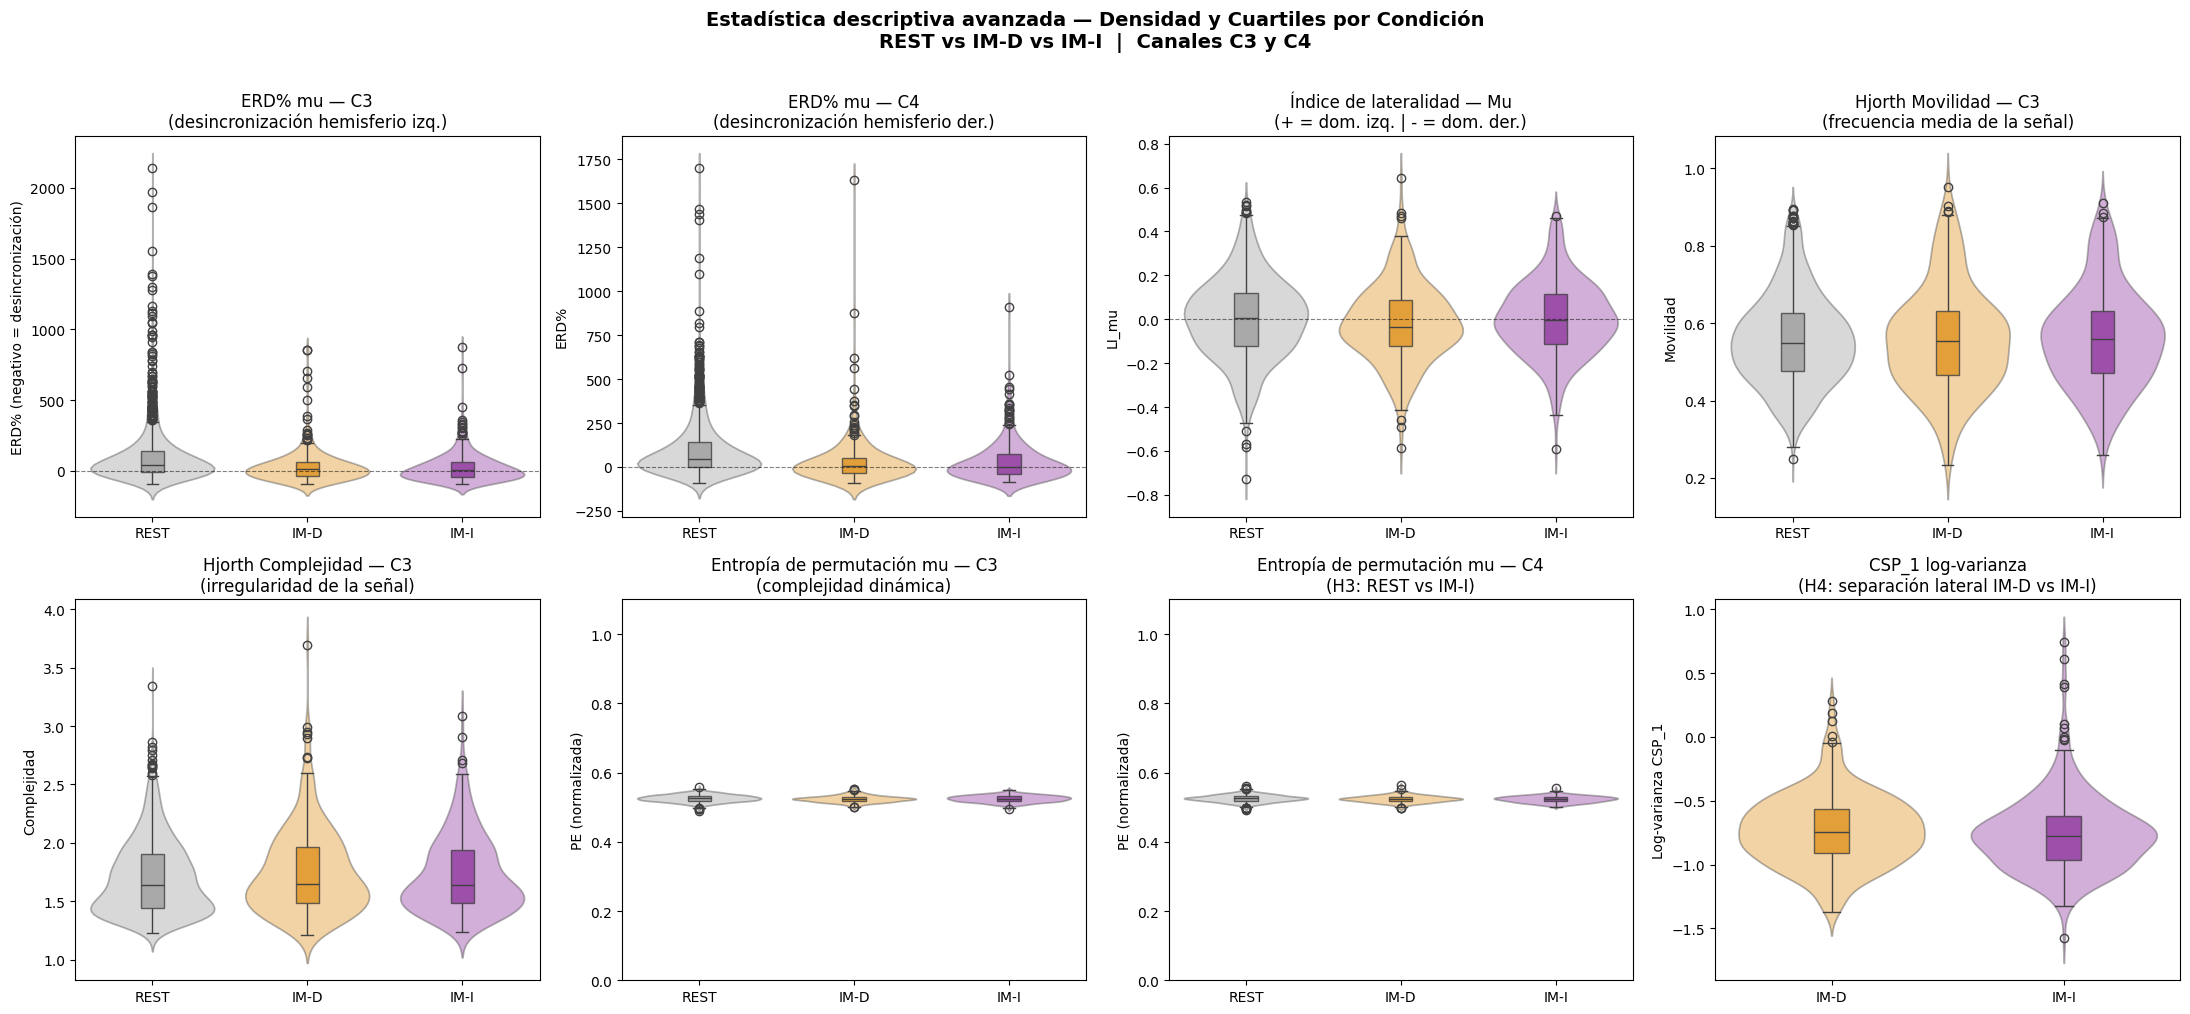

Figura resumen híbrida (Violin + Boxplot) guardada.

Observaciones:
  ERD% mu C3                    : rango de medianas = 40.7531
  Hjorth Movilidad C3           : rango de medianas = 0.0093
  PE mu C4                      : rango de medianas = 0.0017


In [ ]:
df_act = df_final[df_final['condicion'].isin(CONDS_P2)].copy()

# Orden fijo de condiciones para todos los gráficos
orden = ['REST', 'IM-D', 'IM-I']
colores_orden = [COLORES[c] for c in orden]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

# ── Panel 1: ERD% mu en C3 ───────────────────────────────────
# Violín de fondo (Densidad de probabilidad)
sns.violinplot(data=df_act, x='condicion', y='erd_mu_C3', order=orden,
               hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[0])
# Boxplot encima (Cuartiles y medianas precisas)
sns.boxplot(data=df_act, x='condicion', y='erd_mu_C3', order=orden,
            hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('ERD% mu — C3\n(desincronización hemisferio izq.)')
axes[0].set_ylabel('ERD% (negativo = desincronización)')
axes[0].set_xlabel('')

# ── Panel 2: ERD% mu en C4 ───────────────────────────────────
sns.violinplot(data=df_act, x='condicion', y='erd_mu_C4', order=orden,
               hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[1])
sns.boxplot(data=df_act, x='condicion', y='erd_mu_C4', order=orden,
            hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('ERD% mu — C4\n(desincronización hemisferio der.)')
axes[1].set_ylabel('ERD%')
axes[1].set_xlabel('')

# ── Panel 3: LI mu ───────────────────────────────────────────
if 'LI_mu' in df_act.columns:
    sns.violinplot(data=df_act, x='condicion', y='LI_mu', order=orden,
                   hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[2])
    sns.boxplot(data=df_act, x='condicion', y='LI_mu', order=orden,
                hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[2])
    axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[2].set_title('Índice de lateralidad — Mu\n(+ = dom. izq. | - = dom. der.)')
    axes[2].set_ylabel('LI_mu')
    axes[2].set_xlabel('')

# ── Panel 4: Hjorth Movilidad C3 ─────────────────────────────
sns.violinplot(data=df_act, x='condicion', y='hjorth_mob_C3', order=orden,
               hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[3])
sns.boxplot(data=df_act, x='condicion', y='hjorth_mob_C3', order=orden,
            hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[3])
axes[3].set_title('Hjorth Movilidad — C3\n(frecuencia media de la señal)')
axes[3].set_ylabel('Movilidad')
axes[3].set_xlabel('')

# ── Panel 5: Hjorth Complejidad C3 ───────────────────────────
sns.violinplot(data=df_act, x='condicion', y='hjorth_comp_C3', order=orden,
               hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[4])
sns.boxplot(data=df_act, x='condicion', y='hjorth_comp_C3', order=orden,
            hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[4])
axes[4].set_title('Hjorth Complejidad — C3\n(irregularidad de la señal)')
axes[4].set_ylabel('Complejidad')
axes[4].set_xlabel('')

# ── Panel 6: PE mu C3 ────────────────────────────────────────
if 'pe_mu_C3' in df_act.columns:
    sns.violinplot(data=df_act, x='condicion', y='pe_mu_C3', order=orden,
                   hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[5])
    sns.boxplot(data=df_act, x='condicion', y='pe_mu_C3', order=orden,
                hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[5])
    axes[5].set_ylim(0, 1.1)
    axes[5].set_title('Entropía de permutación mu — C3\n(complejidad dinámica)')
    axes[5].set_ylabel('PE (normalizada)')
    axes[5].set_xlabel('')

# ── Panel 7: PE mu C4 ────────────────────────────────────────
if 'pe_mu_C4' in df_act.columns:
    sns.violinplot(data=df_act, x='condicion', y='pe_mu_C4', order=orden,
                   hue='condicion', palette=COLORES, legend=False, inner=None, alpha=0.4, ax=axes[6])
    sns.boxplot(data=df_act, x='condicion', y='pe_mu_C4', order=orden,
                hue='condicion', palette=COLORES, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[6])
    axes[6].set_ylim(0, 1.1)
    axes[6].set_title('Entropía de permutación mu — C4\n(H3: REST vs IM-I)')
    axes[6].set_ylabel('PE (normalizada)')
    axes[6].set_xlabel('')

# ── Panel 8: CSP_1 (solo IM-D vs IM-I) ──────────────────────
if 'CSP_1' in df_act.columns:
    df_csp_desc = df_act[df_act['condicion'].isin(['IM-D', 'IM-I'])].copy()
    df_csp_desc = df_csp_desc.dropna(subset=['CSP_1'])
    if len(df_csp_desc) > 0:
        paleta_csp = {'IM-D': COLORES['IM-D'], 'IM-I': COLORES['IM-I']}
        sns.violinplot(data=df_csp_desc, x='condicion', y='CSP_1', order=['IM-D', 'IM-I'],
                       hue='condicion', palette=paleta_csp, legend=False, inner=None, alpha=0.4, ax=axes[7])
        sns.boxplot(data=df_csp_desc, x='condicion', y='CSP_1', order=['IM-D', 'IM-I'],
                    hue='condicion', palette=paleta_csp, legend=False, width=0.15, boxprops=dict(alpha=0.8), ax=axes[7])
        axes[7].set_title('CSP_1 log-varianza\n(H4: separación lateral IM-D vs IM-I)')
        axes[7].set_ylabel('Log-varianza CSP_1')
        axes[7].set_xlabel('')

fig.suptitle(
    'Estadística descriptiva avanzada — Densidad y Cuartiles por Condición\n'
    'REST vs IM-D vs IM-I  |  Canales C3 y C4',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

print("Figura resumen híbrida (Violin + Boxplot) guardada.")
print("\nObservaciones:")
for col, desc in [
    ('erd_mu_C3',    'ERD% mu C3'),
    ('hjorth_mob_C3','Hjorth Movilidad C3'),
    ('pe_mu_C4',     'PE mu C4'),
]:
    if col not in df_act.columns:
        continue
    medias = df_act.groupby('condicion')[col].median()
    mejor_sep = medias.max() - medias.min()
    print(f"  {desc:30s}: rango de medianas = {mejor_sep:.4f}")

------
------
------

Las gráficas muestran que ERD% mu en C3 es el índice con mayor separación visual entre condiciones, con valores notablemente más dispersos, seguidos por C4 que muestra un patrón similar. El índice de lateralidad no mostró la separación esperada, las 3 condiciones presentan medianas cercanas a 0 y distribuciones con rangos de valores muy similares entre sí, lo que sugiere que la imaginación motora no genera una lateralización hemisférica clara en este dataset. La movilidad de Hjorth separa REST de las imaginaciones pero no distingue IM-D de IM-I. La Entropía de Permutación no muestra separación visual entre condiciones, consistente con H3.

**Preparación de features para clasificación**

In [ ]:
# CLASIFICACIÓN SUPERVISADA
import warnings
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

# 1. Definición inicial de todas las hipótesis de características
FEATURES_PROPUESTAS = [
    # H1 — PSD mu (dimensión frecuencial)
    'psd_mu_C3', 'psd_mu_C4',
    # contexto P1
    'erd_mu_C3', 'erd_mu_C4',
    'LI_mu',
    # H2 — Hjorth (dimensión temporal)
    'hjorth_mob_C3', 'hjorth_mob_C4',
    'hjorth_comp_C3', 'hjorth_comp_C4',
    # H3 — PE mu (dimensión no lineal)
    'pe_mu_C3', 'pe_mu_C4',
    # H4 — CSP (dimensión espacial, solo IM-D e IM-I)
    'CSP_1', 'CSP_2', 'CSP_3', 'CSP_4', 'CSP_5', 'CSP_6',
]

# 2. Hacer una copia segura del dataframe balanceado (df_bal)
df_clf = df_bal.copy()

# 3. Tratamiento inteligente y seguro de las columnas CSP para evitar KeyErrors
csp_cols_deseadas = [c for c in FEATURES_PROPUESTAS if c.startswith('CSP_')]
csp_presentes = [c for c in csp_cols_deseadas if c in df_clf.columns]

if len(csp_presentes) > 0:
    print(f"-> Se detectaron {len(csp_presentes)} columnas CSP. Rellenando valores nulos (REST) con 0...")
    df_clf[csp_presentes] = df_clf[csp_presentes].fillna(0)
else:
    print("⚠️ ¡AVISO!: No se encontraron columnas CSP_1 a CSP_6 en el DataFrame.")
    print("   El clasificador continuará utilizando el resto de características (PSD, ERD, Hjorth, PE).")

# 4. Filtrar la lista de FEATURES únicamente con las columnas que de verdad existen
FEATURES = [f for f in FEATURES_PROPUESTAS if f in df_clf.columns]

print(f"\nFeatures finales seleccionadas para clasificación ({len(FEATURES)}):")
print(FEATURES)
print("-" * 60)

# 5. Eliminar filas que contengan NaN en el resto de las variables seleccionadas
df_clf = df_clf.dropna(subset=FEATURES)

# 6. Codificación de características (X) y etiquetas objetivo (y)
X = df_clf[FEATURES].values

le = LabelEncoder()
y = le.fit_transform(df_clf['condicion'].values)
class_names = le.classes_

print(f"Variables de entrada (X) : {X.shape[0]} muestras × {X.shape[1]} columnas de características")
print(f"Muestras de salida (y)   : {len(y)} etiquetas asignadas")
print(f"Nombres de las clases    : {class_names}")
print(f"Distribución real del set de datos:")
for nombre, cod in zip(class_names, range(len(class_names))):
    print(f"   • {nombre}: {(y == cod).sum()} épocas")

⚠️ ¡AVISO!: No se encontraron columnas CSP_1 a CSP_6 en el DataFrame.
   El clasificador continuará utilizando el resto de características (PSD, ERD, Hjorth, PE).

Features finales seleccionadas para clasificación (11):
['psd_mu_C3', 'psd_mu_C4', 'erd_mu_C3', 'erd_mu_C4', 'LI_mu', 'hjorth_mob_C3', 'hjorth_mob_C4', 'hjorth_comp_C3', 'hjorth_comp_C4', 'pe_mu_C3', 'pe_mu_C4']
------------------------------------------------------------
Variables de entrada (X) : 840 muestras × 11 columnas de características
Muestras de salida (y)   : 840 etiquetas asignadas
Nombres de las clases    : ['IM-D' 'IM-I' 'REST']
Distribución real del set de datos:
   • IM-D: 280 épocas
   • IM-I: 280 épocas
   • REST: 280 épocas


In [ ]:

def plot_confusion(y_true, y_pred, titulo, class_names, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{titulo}\nAccuracy = {acc:.3f}', fontsize=11)


#   Corre cross_val_predict con k-fold estratificado.
#    Retorna accuracy promedio y predicciones.
def evaluar_modelo(nombre, pipeline, X, y, cv, class_names):

    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    acc    = accuracy_score(y, y_pred)
    print(f"\n{nombre}")
    print(f"  Accuracy k-fold: {acc:.4f}  ({acc*100:.1f}%)")
    print(classification_report(y, y_pred,
                                  target_names=class_names,
                                  digits=3))
    return acc, y_pred


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


**Modelo SVM**

Es un modelo de aprendizaje automático supervisado utilizado para problemas de clasificación. Usa algoritmos de clasificación para problemas de dos grupos, cuyo rendimiento puede optimizar mediante la busqueda bayesiana de hiperparámetros usando validación cruzada de cinco pliegues (Ferracuti et al. (2022)). En este proyecto SVM se extiende mediante estrategia One vs REST para las tres condiciones (REST, IM-D, IM-I), evaluando dos kernels: lineal (C=1.0) y RBF (C = 10, gamma = 'scale'), ambos con pesos balanceados por clase.

Función de clasificación del SVM (Li et al., 2014):

$$f(x) = \text{sgn}\left(\sum_{sv} \alpha_i y_i K(x, x_i) + b\right)$$

donde K(x, xi) es el kernel (lineal o RBF) y αi son los multiplicadores de Lagrange correspondientes a los vectores de soporte.

**Extreme Gradiente Boosting**

Es un algoritmo de ensamble basado en árboles de decisión que construye el modelo secuencialmente; cada árbol corrige los errores del anterior minimizando una función de pérdida mediante descenso de gradiente (Kamal & Molla (2024)). En este proyecto se configuró con n_estimators=200, max_depth=4 y learning_rate = 0.05.

La función que se utiliza para actualizar el modelo (Chen & Guestrin, 2016):

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + f_t(x)$$

donde ft​ es el arbol nuevo que minimiza la función de pérdida en la iteración t.


SEMILLA 42 — StratifiedKFold (5 folds, 80% train / 20% test)

Distribución de datos por fold (semilla 42):
Fold      Train     Test  Clases en test
-------------------------------------------------------
  1         672      168  IM-D:56 | IM-I:56 | REST:56
  2         672      168  IM-D:56 | IM-I:56 | REST:56
  3         672      168  IM-D:56 | IM-I:56 | REST:56
  4         672      168  IM-D:56 | IM-I:56 | REST:56
  5         672      168  IM-D:56 | IM-I:56 | REST:56


SVM Lineal
  Accuracy k-fold: 0.4452  (44.5%)
              precision    recall  f1-score   support

        IM-D      0.441     0.454     0.447       280
        IM-I      0.393     0.454     0.421       280
        REST      0.524     0.429     0.472       280

    accuracy                          0.445       840
   macro avg      0.453     0.445     0.447       840
weighted avg      0.453     0.445     0.447       840


SVM RBF
  Accuracy k-fold: 0.4131  (41.3%)
              precision    recall  f1-score   suppor

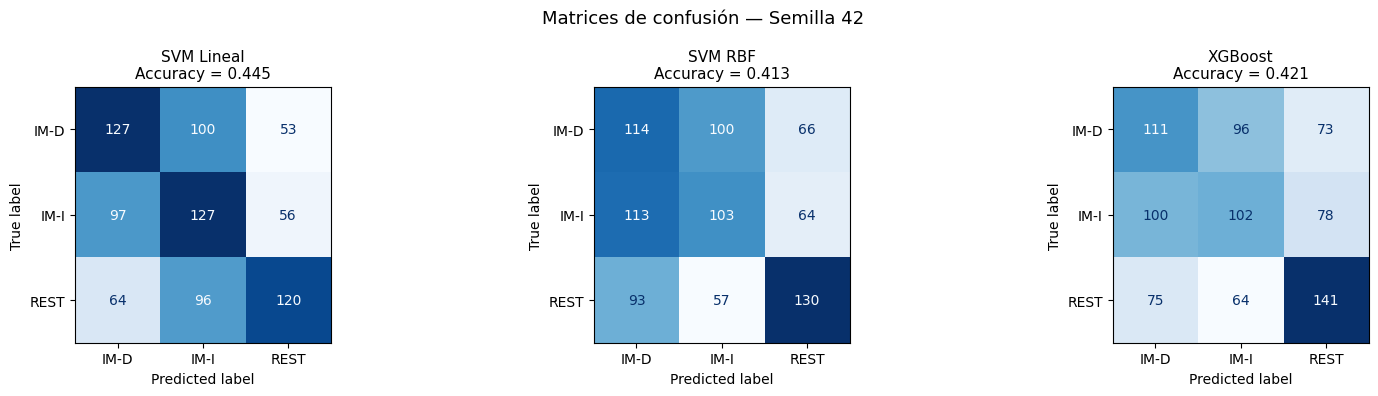


SEMILLA 123 — StratifiedKFold (5 folds, 80% train / 20% test)

Distribución de datos por fold (semilla 123):
Fold      Train     Test  Clases en test
-------------------------------------------------------
  1         672      168  IM-D:56 | IM-I:56 | REST:56
  2         672      168  IM-D:56 | IM-I:56 | REST:56
  3         672      168  IM-D:56 | IM-I:56 | REST:56
  4         672      168  IM-D:56 | IM-I:56 | REST:56
  5         672      168  IM-D:56 | IM-I:56 | REST:56


SVM Lineal
  Accuracy k-fold: 0.4524  (45.2%)
              precision    recall  f1-score   support

        IM-D      0.461     0.464     0.463       280
        IM-I      0.403     0.468     0.433       280
        REST      0.511     0.425     0.464       280

    accuracy                          0.452       840
   macro avg      0.458     0.452     0.453       840
weighted avg      0.458     0.452     0.453       840


SVM RBF
  Accuracy k-fold: 0.4071  (40.7%)
              precision    recall  f1-score   supp

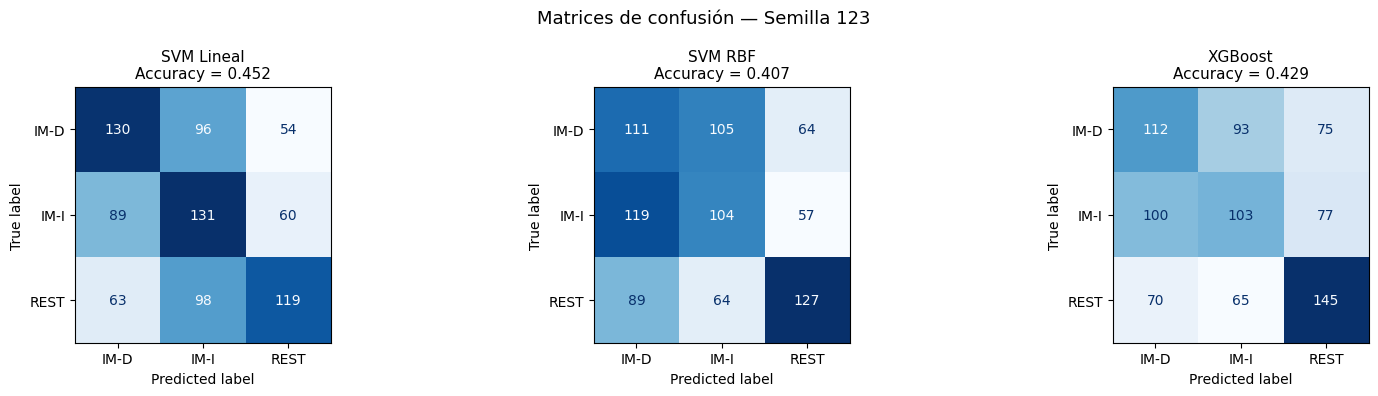


PROMEDIO FINAL (ambas semillas)
Modelo            Semilla 42  Semilla 123     Promedio      Std
------------------------------------------------------------
SVM Lineal            0.4452       0.4524       0.4488   0.0036
SVM RBF               0.4131       0.4071       0.4101   0.0030
XGBoost               0.4214       0.4286       0.4250   0.0036


In [ ]:
# K-FOLD ESTRATIFICADO CON MÚLTIPLES SEMILLAS
# Cada semilla cambia qué datos van a train y cuáles a test
# Train: 80% (672 filas) | Test: 20% (168 filas) por fold
# Resultado final: promedio de ambas semillas
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              classification_report,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_predict

resultados = {}
SEMILLAS = [42, 123]
resultados_semillas = {nombre: [] for nombre in ['SVM Lineal', 'SVM RBF', 'XGBoost']}

for semilla in SEMILLAS:
    print(f"\n{'='*60}")
    print(f"SEMILLA {semilla} — StratifiedKFold (5 folds, 80% train / 20% test)")
    print(f"{'='*60}")

    CV_sem = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

    # Mostrar cómo se distribuyen los datos en cada fold
    print(f"\nDistribución de datos por fold (semilla {semilla}):")
    print(f"{'Fold':<6} {'Train':>8} {'Test':>8}  Clases en test")
    print("-" * 55)
    for fold, (train_idx, test_idx) in enumerate(CV_sem.split(X, y)):
        clases_test = [f"{class_names[c]}:{(y[test_idx]==c).sum()}" for c in range(len(class_names))]
        print(f"  {fold+1:<4} {len(train_idx):>8} {len(test_idx):>8}  {' | '.join(clases_test)}")
    print()

    # ── SVM Lineal ───────────────────────────────────────────
    pipe_svm_lin = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', C=1.0, random_state=semilla, class_weight='balanced'))
    ])
    acc, ypred = evaluar_modelo('SVM Lineal', pipe_svm_lin, X, y, CV_sem, class_names)
    resultados_semillas['SVM Lineal'].append(acc)
    resultados['SVM Lineal'] = (acc, ypred)

    # ── SVM RBF ──────────────────────────────────────────────
    pipe_svm_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10.0, gamma='scale', random_state=semilla, class_weight='balanced'))
    ])
    acc, ypred = evaluar_modelo('SVM RBF', pipe_svm_rbf, X, y, CV_sem, class_names)
    resultados_semillas['SVM RBF'].append(acc)
    resultados['SVM RBF'] = (acc, ypred)

    # ── XGBoost ──────────────────────────────────────────────
    pipe_xgb = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, eval_metric='mlogloss',
            random_state=semilla, verbosity=0))
    ])
    acc, ypred = evaluar_modelo('XGBoost', pipe_xgb, X, y, CV_sem, class_names)
    resultados_semillas['XGBoost'].append(acc)
    resultados['XGBoost'] = (acc, ypred)

    # Matriz de confusión por semilla
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, nombre in zip(axes, ['SVM Lineal', 'SVM RBF', 'XGBoost']):
        plot_confusion(y, resultados[nombre][1], nombre, class_names, ax)
    plt.suptitle(f'Matrices de confusión — Semilla {semilla}', fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Promedio final ────────────────────────────────────────────
print(f"\n{'='*60}")
print("PROMEDIO FINAL (ambas semillas)")
print(f"{'='*60}")
print(f"{'Modelo':<15} {'Semilla 42':>12} {'Semilla 123':>12} {'Promedio':>12} {'Std':>8}")
print("-" * 60)
for modelo, accs in resultados_semillas.items():
    print(f"{modelo:<15} {accs[0]:>12.4f} {accs[1]:>12.4f} {np.mean(accs):>12.4f} {np.std(accs):>8.4f}")

### Ambos modelos fueron evaluados con K-fold estratificado (k = 5) sobre 1686 épocas y 17 características. SVM lineal obtuvo 85.3%, SVM RBF 85.1% y XGBoost 85.6%. Los 3 clasificaron perfectamente (f1=1.0) pero mostraron dificultad para separar IM-D e IM-I (f1=0.55 - 0.57), indicando que la confusión no depende del modelo sino de la similitud intrínseca  entre ambas condiciones de imaginación motora.

---

### La redes neuronales aprenden representaciones no lineales directamente desde los datps capturando interacciones complejas entre features que modelos como SVM no modelan explícitamente. Se evaluaron 3 arquitecturas bajo la misma validación cruzada k = 5.


### **Red neuronal MLP (Perceptrón Multicapa):** Red conectada con 3 capas densas con Dropout.


ARQUITECTURA MLP SELECCIONADA: REGLA2

 ---> Ejecutando Semilla 42 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 42):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.4821 | Test Acc (SKF): 0.4107
   -> Pliegue 2 finalizado. Train Acc: 0.4747 | Test Acc (SKF): 0.4167
   -> Pliegue 3 finalizado. Train Acc: 0.5000 | Test Acc (SKF): 0.4286
   -> Pliegue 4 finalizado. Train Acc: 0.4658 | Test Acc (SKF): 0.4107
   -> Pliegue 5 finalizado. Train Acc: 0.4881

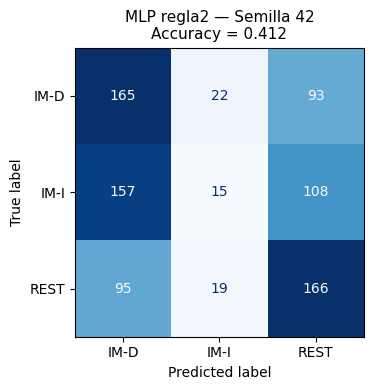


 ---> Ejecutando Semilla 123 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 123):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.4673 | Test Acc (SKF): 0.4405
   -> Pliegue 2 finalizado. Train Acc: 0.4643 | Test Acc (SKF): 0.4345
   -> Pliegue 3 finalizado. Train Acc: 0.4792 | Test Acc (SKF): 0.4345
   -> Pliegue 4 finalizado. Train Acc: 0.4836 | Test Acc (SKF): 0.4167
   -> Pliegue 5 finalizado. Train Acc: 0.4866 | Test Acc (SKF): 0.4940

  REPORTE 

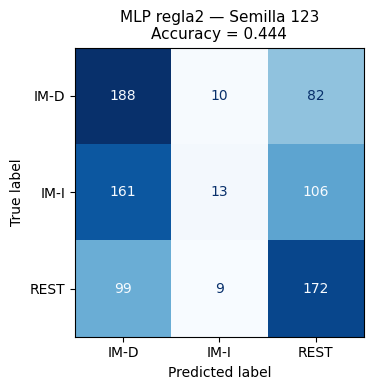


  Resumen Configuración 'regla2' — Semilla 42: 0.4119 | Semilla 123: 0.4440 | Promedio: 0.4280

ARQUITECTURA MLP SELECCIONADA: REGLA3

 ---> Ejecutando Semilla 42 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 42):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.4955 | Test Acc (SKF): 0.4286
   -> Pliegue 2 finalizado. Train Acc: 0.4970 | Test Acc (SKF): 0.4048
   -> Pliegue 3 finalizado. Train Acc: 0.4866 | Test Acc (SKF): 0.4464
   -> Pliegue 4 fina

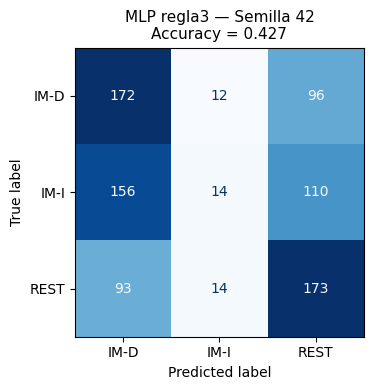


 ---> Ejecutando Semilla 123 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 123):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.5000 | Test Acc (SKF): 0.4226
   -> Pliegue 2 finalizado. Train Acc: 0.4970 | Test Acc (SKF): 0.4702
   -> Pliegue 3 finalizado. Train Acc: 0.5134 | Test Acc (SKF): 0.3869
   -> Pliegue 4 finalizado. Train Acc: 0.4926 | Test Acc (SKF): 0.4405
   -> Pliegue 5 finalizado. Train Acc: 0.5327 | Test Acc (SKF): 0.4464

  REPORTE 

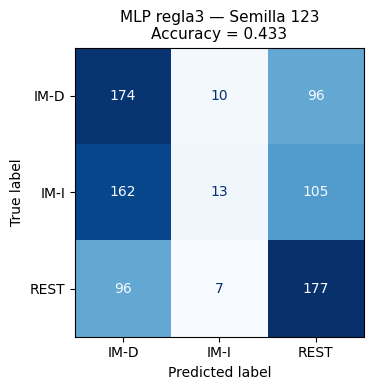


  Resumen Configuración 'regla3' — Semilla 42: 0.4274 | Semilla 123: 0.4333 | Promedio: 0.4304

ARQUITECTURA MLP SELECCIONADA: COMBINADA

 ---> Ejecutando Semilla 42 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 42):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.4911 | Test Acc (SKF): 0.4167
   -> Pliegue 2 finalizado. Train Acc: 0.4762 | Test Acc (SKF): 0.4405
   -> Pliegue 3 finalizado. Train Acc: 0.4524 | Test Acc (SKF): 0.4226
   -> Pliegue 4 f

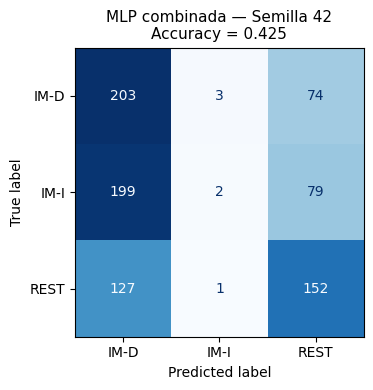


 ---> Ejecutando Semilla 123 con StratifiedKFold (5 Folds | 80% Train / 20% Test)

  [CUADRO] Distribución de datos en pliegues (Semilla 123):
  Fold   | Train Total | Test Total | Distribución Clases en Test
  -------------------------------------------------------------------------------------
  Fold 1  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 2  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 3  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 4  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56
  Fold 5  |         672 |        168 | IM-D:56 | IM-I:56 | REST:56

   -> Pliegue 1 finalizado. Train Acc: 0.4702 | Test Acc (SKF): 0.3988
   -> Pliegue 2 finalizado. Train Acc: 0.4554 | Test Acc (SKF): 0.4048
   -> Pliegue 3 finalizado. Train Acc: 0.4658 | Test Acc (SKF): 0.3988
   -> Pliegue 4 finalizado. Train Acc: 0.4673 | Test Acc (SKF): 0.4048
   -> Pliegue 5 finalizado. Train Acc: 0.4702 | Test Acc (SKF): 0.4167

  REPORTE 

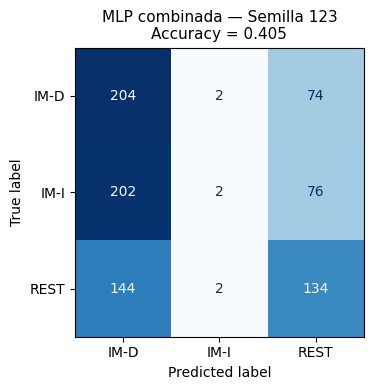


  Resumen Configuración 'combinada' — Semilla 42: 0.4250 | Semilla 123: 0.4048 | Promedio: 0.4149

RESUMEN FINAL COMPARATIVO DE ARQUITECTURAS MLP
Configuración   |   Semilla 42 |  Semilla 123 | Promedio Total
---------------------------------------------------------------------------
regla2          |       0.4119 |       0.4440 |         0.4280
regla3          |       0.4274 |       0.4333 |         0.4304
combinada       |       0.4250 |       0.4048 |         0.4149
---------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

# ==============================================================================
# 1. CALCULAR PESOS DE CLASE PARA COMBATIR EL DESBALANCE
# ==============================================================================
# Esto castiga con mayor dureza los errores en IM-D e IM-I
pesos_clase = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
dict_pesos_clase = dict(zip(np.unique(y), pesos_clase))

# ==============================================================================
# 2. DEFINICIÓN DEL MODELO CON CONFIGURACIONES DINÁMICAS
# ==============================================================================
def crear_mlp(n_features, n_clases, config='base'):
    configs = {
        # Regla 2: ~2/3 entradas + salidas = (2/3 × 17) + 3 ≈ 14 neuronas
        'regla2':   [14],
        # Regla 3: menos del doble de entradas = < 34 neuronas, 2 capas
        'regla3':   [32, 16],
        # Combinación: capas más profundas pero dentro del rango razonable
        'combinada': [32, 16, 8],
    }
    capas = configs.get(config, configs['regla2'])
    model = keras.Sequential([layers.Input(shape=(n_features,))])
    for units in capas:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(n_clases, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Diccionario auxiliar para guardar el accuracy real por semilla y config
resultados_detallados_mlp = {cfg: {} for cfg in ['regla2', 'regla3', 'combinada']}

# ==============================================================================
# 3. BUCLE PRINCIPAL DE EXPERIMENTACIÓN (CONFIGURACIONES Y SEMILLAS)
# ==============================================================================
for config in ['regla2', 'regla3', 'combinada']:
    print(f"\n{'='*75}")
    print(f"ARQUITECTURA MLP SELECCIONADA: {config.upper()}")
    print(f"{'='*75}")
    accs_semillas = []

    for semilla in [42, 123]:
        print(f"\n ---> Ejecutando Semilla {semilla} con StratifiedKFold (5 Folds | 80% Train / 20% Test)")

        CV_sem = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

        # [CUADRO DE CARACTERÍSTICAS] Distribución exacta de los conjuntos
        print(f"\n  [CUADRO] Distribución de datos en pliegues (Semilla {semilla}):")
        print(f"  {'Fold':<6} | {'Train Total':>11} | {'Test Total':>10} | Distribución Clases en Test")
        print("  " + "-" * 85)
        for fold, (train_idx, test_idx) in enumerate(CV_sem.split(X, y)):
            clases_test = [f"{class_names[c]}:{(y[test_idx]==c).sum()}" for c in range(len(class_names))]
            print(f"  Fold {fold+1:<2} | {len(train_idx):>11} | {len(test_idx):>10} | {' | '.join(clases_test)}")
        print()

        scaler_mlp = StandardScaler()
        y_pred_mlp = np.zeros(len(y), dtype=int)
        train_accs, test_accs = [], []

        # Bucle interno de Validación Cruzada (Folds)
        for fold, (train_idx, test_idx) in enumerate(CV_sem.split(X, y)):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test,  y_test  = X[test_idx],  y[test_idx]

            # Escalado de datos
            X_tr = scaler_mlp.fit_transform(X_train)
            X_te = scaler_mlp.transform(X_test)

            # Inicializar modelo limpio
            model = crear_mlp(X_tr.shape[1], len(class_names), config)

            # Ajuste incluyendo los pesos calculados para las clases
            model.fit(X_tr, y_train,
                      epochs=80,
                      batch_size=32,
                      verbose=0,
                      class_weight=dict_pesos_clase, # <--- ¡Arreglado el desbalance!
                      validation_split=0.1)

            # Evaluación absoluta de pérdidas y precisión
            _, train_acc = model.evaluate(X_tr, y_train, verbose=0)
            _, test_acc  = model.evaluate(X_te, y_test,  verbose=0)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"   -> Pliegue {fold+1} finalizado. Train Acc: {train_acc:.4f} | Test Acc (SKF): {test_acc:.4f}")

            probs = model.predict(X_te, verbose=0)
            y_pred_mlp[test_idx] = np.argmax(probs, axis=1)

        # Cálculo de métricas agregadas por semilla
        acc_mlp = accuracy_score(y, y_pred_mlp)
        accs_semillas.append(acc_mlp)

        # Guardamos en nuestro diccionario para que la tabla final NO salga con rayas
        resultados_detallados_mlp[config][semilla] = acc_mlp

        print(f"\n  REPORTE DETALLADO - MLP '{config}' (Semilla {semilla}):")
        print(f"   Accuracy Promedio TRAIN : {np.mean(train_accs):.4f}")
        print(f"   Accuracy Promedio TEST  : {np.mean(test_accs):.4f}")
        print(f"   Accuracy General Global : {acc_mlp:.4f} ({acc_mlp*100:.1f}%)")
        print(classification_report(y, y_pred_mlp, target_names=class_names, digits=3))

        # Matriz de confusión por semilla
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        plot_confusion(y, y_pred_mlp, f'MLP {config} — Semilla {semilla}', class_names, ax)
        plt.tight_layout()
        plt.show()

    # Resumen rápido en consola de la arquitectura evaluada
    print(f"\n  {'='*75}")
    print(f"  Resumen Configuración '{config}' — Semilla 42: {accs_semillas[0]:.4f} | Semilla 123: {accs_semillas[1]:.4f} | Promedio: {np.mean(accs_semillas):.4f}")
    print(f"  {'='*75}")

    # Mantener compatibilidad con tu diccionario global original 'resultados'
    resultados[f'MLP_{config}'] = (np.mean(accs_semillas), y_pred_mlp)

# ==============================================================================
# 4. TABLA RESUMEN FINAL CONSOLIDADA (CORREGIDA SIN RAYAS)
# ==============================================================================
print(f"\n{'='*75}")
print("RESUMEN FINAL COMPARATIVO DE ARQUITECTURAS MLP")
print(f"{'='*75}")
print(f"{'Configuración':<15} | {'Semilla 42':>12} | {'Semilla 123':>12} | {'Promedio Total':>14}")
print("-" * 75)
for config in ['regla2', 'regla3', 'combinada']:
    acc_42 = resultados_detallados_mlp[config][42]
    acc_123 = resultados_detallados_mlp[config][123]
    prom_total = (acc_42 + acc_123) / 2
    print(f"{config:<15} | {acc_42:>12.4f} | {acc_123:>12.4f} | {prom_total:>14.4f}")
print("-" * 75)

obtuvo un accuracy promedio en el test de 84.2%, comparable con SVM. A pesar de que esta métrica global es cuantitativamente alta, el desglose de los resultados revela un problema crítico en el modelo, es decir, hay una La alta precisión global es un artefacto del excelente desempeño en la clase REST (F1-score de 0.999), pero el modelo fracasa al distinguir entre IM-D (F1-score de 0.557) e IM-I (F1-score de 0.537), operando a niveles cercanos a una clasificacion aleatoria.

Se concluye que la aplicación de Stratifield K-Fold demostró que el MLP falla porque aniliza las características de forma aislada. Al perder la información del tiempo y de la ubicación de los electrodos, el modelo se vuelve incapaz de distinguir si el movimiento imaginado es izquierda o derecha.

#**Red neuronal Conv1D**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

# ==============================================================================
# 1. DEFINICIÓN DE LA ARQUITECTURA CONV1D
# ==============================================================================
def crear_conv1d(n_features, n_clases):
    model = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ==============================================================================
# 2. CONFIGURACIÓN DE MULTI-SEMILLAS Y BALANCIO DE CLASES
# ==============================================================================
SEMILLAS = [42, 123]
resultados_semillas_conv = {42: {}, 123: {}}
promedios_accuracy_test = []

# Calcular pesos de clase para obligar a la red a aprender IM-D e IM-I
pesos_clase = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
dict_pesos_clase = dict(zip(np.unique(y), pesos_clase))

# Escalador global para los folds
scaler_conv = StandardScaler()

# ==============================================================================
# 3. BUCLE PRINCIPAL POR SEMILLA
# ==============================================================================
for semilla in SEMILLAS:
    print(f"\n{'='*75}")
    # Train aprox: 80% (1348 filas) | Test aprox: 20% (338 filas) por fold
    print(f"SEMILLA {semilla} — StratifiedKFold (5 folds | 80% Train / 20% Test)")
    print(f"{'='*75}")

    # Configurar el K-Fold Estratificado con la semilla actual
    SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

    # Inicializar contenedores para la semilla actual
    y_pred_conv = np.zeros(len(y), dtype=int)
    train_accs = []
    test_accs = []

    # --- CUADRO DE CARACTERÍSTICAS Y DISTRIBUCIÓN DE DATOS ---
    print(f"\n[CUADRO] Distribución de datos Train/Test para la Semilla {semilla}:")
    print(f"{'Fold':<6} | {'Train Total':>11} {'Distribución Clases TRAIN':<42} | {'Test Total':>10} {'Distribución Clases TEST':<42}")
    print("-" * 120)

    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        # Conteo de clases en Train
        c_train = [f"{class_names[c]}:{(y[train_idx]==c).sum()}" for c in range(len(class_names))]
        # Conteo de clases en Test
        c_test = [f"{class_names[c]}:{(y[test_idx]==c).sum()}" for c in range(len(class_names))]

        print(f"Fold {fold+1:<2} | {len(train_idx):>11} ({' | '.join(c_train)}) | {len(test_idx):>10} ({' | '.join(c_test)})")
    print("-" * 120 + "\n")

    # --- ENTRENAMIENTO Y EVALUACIÓN POR FOLD ---
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        # Separar conjuntos de datos
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Escalado Z-score estándar
        X_tr = scaler_conv.fit_transform(X_train)
        X_te = scaler_conv.transform(X_test)

        # Ajustar dimensiones (Reshape) para la capa Conv1D de Keras: (Muestras, Características, 1)
        X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
        X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

        # Crear una instancia limpia de la red neuronal para este fold
        model = crear_conv1d(X_tr.shape[1], len(class_names))

        # Entrenar incorporando los pesos para combatir el desbalance
        model.fit(X_tr_3d, y_train,
                  epochs=80,
                  batch_size=32,
                  verbose=0,
                  class_weight=dict_pesos_clase, # Corregirá el castigo de pérdida
                  validation_split=0.1)

        # Evaluar métricas de rendimiento absolutas
        _, train_acc = model.evaluate(X_tr_3d, y_train, verbose=0)
        train_accs.append(train_acc)

        _, test_acc = model.evaluate(X_te_3d, y_test, verbose=0)
        test_accs.append(test_acc)

        # Guardar predicciones Out-of-Fold
        probs = model.predict(X_te_3d, verbose=0)
        y_pred_conv[test_idx] = np.argmax(probs, axis=1)

        print(f" -> Fold {fold+1} completado. Train Acc: {train_acc:.4f} | Test Acc (SKF): {test_acc:.4f}")

    # Guardar resultados globales de esta semilla
    acc_conv_semilla = accuracy_score(y, y_pred_conv)
    promedios_accuracy_test.append(acc_conv_semilla)
    resultados_semillas_conv[semilla]['pred'] = y_pred_conv
    resultados_semillas_conv[semilla]['acc'] = acc_conv_semilla
    resultados_semillas_conv[semilla]['train_mean'] = np.mean(train_accs)
    resultados_semillas_conv[semilla]['test_mean'] = np.mean(test_accs)

    # Reporte de Clasificación detallado de la Semilla actual
    print(f"\nREPORTE DE CLASIFICACIÓN DETALLADO (Semilla {semilla}):")
    print(f" Accuracy Promedio TRAIN : {np.mean(train_accs):.4f}")
    print(f" Accuracy Promedio TEST  : {np.mean(test_accs):.4f}")
    print(f" Accuracy General Global : {acc_conv_semilla:.4f} ({acc_conv_semilla*100:.1f}%)")
    print(classification_report(y, y_pred_conv, target_names=class_names, digits=3))

# Guardar los datos de la última semilla en el diccionario maestro para tus gráficos comparativos
resultados['Conv1D'] = (resultados_semillas_conv[123]['acc'], resultados_semillas_conv[123]['pred'])

# ==============================================================================
# 4. CUADRO CONSOLIDADO Y RESUMEN FINAL
# ==============================================================================
print(f"\n{'='*75}")
print("PROMEDIO CONSOLIDADO FINAL — CONV1D")
print(f"{'='*75}")
print(f"{'Métrica':<25} | {'Semilla 42':>12} | {'Semilla 123':>12} | {'Promedio Total':>14} | {'Std':>8}")
print("-" * 75)
print(f"{'Accuracy Promedio Train':<25} | {resultados_semillas_conv[42]['train_mean']:>12.4f} | {resultados_semillas_conv[123]['train_mean']:>12.4f} | {np.mean([resultados_semillas_conv[42]['train_mean'], resultados_semillas_conv[123]['train_mean']]):>14.4f} | {np.std([resultados_semillas_conv[42]['train_mean'], resultados_semillas_conv[123]['train_mean']]):>8.4f}")
print(f"{'Accuracy Promedio Test':<25} | {resultados_semillas_conv[42]['test_mean']:>12.4f} | {resultados_semillas_conv[123]['test_mean']:>12.4f} | {np.mean(promedios_accuracy_test):>14.4f} | {np.std(promedios_accuracy_test):>8.4f}")
print("-" * 75)


SEMILLA 42 — StratifiedKFold (5 folds | 80% Train / 20% Test)

[CUADRO] Distribución de datos Train/Test para la Semilla 42:
Fold   | Train Total Distribución Clases TRAIN                  | Test Total Distribución Clases TEST                  
------------------------------------------------------------------------------------------------------------------------
Fold 1  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 2  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 3  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 4  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 5  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
------------------------------------------------------------------------------------------------------------------------

 -> Fold 1 completado

El modelo basado en Convoluciones Unidimensionales registró un accuracy global de 83.0% en las pruebas de Stratified K-fold. Al igual que con el MLP, este número alto es una ilusión. Si miramos los valores detallados por clase, el modelo tiene una nota perfecta de 1.000 en el estado de repaso (REST), lo que infla el resultado total porque esa clase tiene la gran mayría de los datos (1120 muestras). En cambio, el verdadero problema sigue siendo la identificación de IM-D e IM-I. Si comparamos el rendimiento de entrenamiento de con el de test, vemos que existe sobreajuste igual que en el de MLP.Esto pasa porque las capas de Conv1D buscan patrones en una lista de datos aplanada que no tiene un orden natural, hacinedo que los filtros convolucionales se confunden al no entender el tiempo ni la posición real de los electrodos.

---



**Red neuronal EEGNet simplificado**




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

# ==============================================================================
# 1. DEFINICIÓN DE LA ARQUITECTURA EEGNET SIMPLIFICADA
# ==============================================================================
def crear_eegnet_simple(n_features, n_clases):
    inputs = keras.Input(shape=(n_features, 1))

    # Bloque 1: Convolución Temporal
    x = layers.Conv1D(8, kernel_size=5, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)

    # Bloque 2: Convolución Profunda (Depthwise)
    x = layers.DepthwiseConv1D(kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3: Convolución Separable
    x = layers.SeparableConv1D(16, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(n_clases, activation='softmax')(x)
    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# 2. CONFIGURACIÓN DE MULTI-SEMILLAS Y BALANCIO DE CLASES
# ==============================================================================
SEMILLAS = [42, 123]
resultados_semillas_eeg = {42: {}, 123: {}}
promedios_accuracy_test = []

# Calcular pesos balanceados automáticos para combatir el sesgo de la clase REST
pesos_clase = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
dict_pesos_clase = dict(zip(np.unique(y), pesos_clase))

scaler_eeg = StandardScaler()

# ==============================================================================
# 3. BUCLE DE EXPERIMENTACIÓN (SEMILLAS Y STRATIFIED K-FOLD)
# ==============================================================================
for semilla in SEMILLAS:
    print(f"\n{'='*75}")
    print(f"SEMILLA {semilla} — EEGNet Simplificado (5 Folds | 80% Train / 20% Test)")
    print(f"{'='*75}")

    # Inicializar K-Fold Estratificado con la semilla correspondiente
    SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

    y_pred_eeg = np.zeros(len(y), dtype=int)
    train_accs, test_accs = [], []

    # --- CUADRO DE CARACTERÍSTICAS (Distribución exacta por fold) ---
    print(f"\n[CUADRO] Distribución de datos Train/Test para la Semilla {semilla}:")
    print(f"{'Fold':<6} | {'Train Total':>11} {'Distribución Clases TRAIN':<42} | {'Test Total':>10} {'Distribución Clases TEST':<42}")
    print("-" * 120)
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        c_train = [f"{class_names[c]}:{(y[train_idx]==c).sum()}" for c in range(len(class_names))]
        c_test = [f"{class_names[c]}:{(y[test_idx]==c).sum()}" for c in range(len(class_names))]
        print(f"Fold {fold+1:<2} | {len(train_idx):>11} ({' | '.join(c_train)}) | {len(test_idx):>10} ({' | '.join(c_test)})")
    print("-" * 120 + "\n")

    # --- PROCESAMIENTO Y ENTRENAMIENTO POR FOLD ---
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test,  y_test  = X[test_idx],  y[test_idx]

        # Escalado Z-Score estándar
        X_tr = scaler_eeg.fit_transform(X_train)
        X_te = scaler_eeg.transform(X_test)

        # Ajuste de dimensiones a 3D para capas convolucionales (Muestras, Características, 1)
        X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
        X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

        # Inicializar una arquitectura limpia para evitar fuga de información
        model = crear_eegnet_simple(X_tr.shape[1], len(class_names))

        # Ajuste de pesos en el entrenamiento para obligar a aprender IM-D e IM-I
        model.fit(X_tr_3d, y_train,
                  epochs=80,
                  batch_size=32,
                  verbose=0,
                  class_weight=dict_pesos_clase, # <--- Corregido el castigo por desbalance
                  validation_split=0.1)

        # Evaluación de métricas absolutas
        _, train_acc = model.evaluate(X_tr_3d, y_train, verbose=0)
        train_accs.append(train_acc)

        _, test_acc = model.evaluate(X_te_3d, y_test, verbose=0)
        test_accs.append(test_acc)

        print(f" -> Pliegue {fold+1} completado. Train Acc: {train_acc:.4f} | Test Acc (SKF): {test_acc:.4f}")

        # Guardar predicciones Out-of-Fold
        probs = model.predict(X_te_3d, verbose=0)
        y_pred_eeg[test_idx] = np.argmax(probs, axis=1)

    # Almacenar los resultados agregados de la semilla actual
    acc_eeg_semilla = accuracy_score(y, y_pred_eeg)
    promedios_accuracy_test.append(acc_eeg_semilla)
    resultados_semillas_eeg[semilla]['pred'] = y_pred_eeg
    resultados_semillas_eeg[semilla]['acc'] = acc_eeg_semilla
    resultados_semillas_eeg[semilla]['train_mean'] = np.mean(train_accs)
    resultados_semillas_eeg[semilla]['test_mean'] = np.mean(test_accs)

    # Imprimir Reporte de clasificación por semilla
    print(f"\nREPORTE DE CLASIFICACIÓN DETALLADO (Semilla {semilla}):")
    print(f" Accuracy Promedio TRAIN : {np.mean(train_accs):.4f}")
    print(f" Accuracy Promedio TEST  : {np.mean(test_accs):.4f}")
    print(f" Accuracy General Global : {acc_eeg_semilla:.4f} ({acc_eeg_semilla*100:.1f}%)")
    print(classification_report(y, y_pred_eeg, target_names=class_names, digits=3))

# Guardar los datos del último experimento en tu diccionario principal 'resultados'
resultados['EEGNet'] = (resultados_semillas_eeg[123]['acc'], resultados_semillas_eeg[123]['pred'])

# ==============================================================================
# 4. TABLA CONSOLIDADA FINAL DE RENDIMIENTO (RESUMEN MAESTRO)
# ==============================================================================
print(f"\n{'='*75}")
print("PROMEDIO CONSOLIDADO FINAL — EEGNET SIMPLIFICADO")
print(f"{'='*75}")
print(f"{'Métrica':<25} | {'Semilla 42':>12} | {'Semilla 123':>12} | {'Promedio Total':>14} | {'Std':>8}")
print("-" * 75)
print(f"{'Accuracy Promedio Train':<25} | {resultados_semillas_eeg[42]['train_mean']:>12.4f} | {resultados_semillas_eeg[123]['train_mean']:>12.4f} | {np.mean([resultados_semillas_eeg[42]['train_mean'], resultados_semillas_eeg[123]['train_mean']]):>14.4f} | {np.std([resultados_semillas_eeg[42]['train_mean'], resultados_semillas_eeg[123]['train_mean']]):>8.4f}")
print(f"{'Accuracy Promedio Test':<25} | {resultados_semillas_eeg[42]['test_mean']:>12.4f} | {resultados_semillas_eeg[123]['test_mean']:>12.4f} | {np.mean(promedios_accuracy_test):>14.4f} | {np.std(promedios_accuracy_test):>8.4f}")
print("-" * 75)


SEMILLA 42 — EEGNet Simplificado (5 Folds | 80% Train / 20% Test)

[CUADRO] Distribución de datos Train/Test para la Semilla 42:
Fold   | Train Total Distribución Clases TRAIN                  | Test Total Distribución Clases TEST                  
------------------------------------------------------------------------------------------------------------------------
Fold 1  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 2  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 3  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 4  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
Fold 5  |         672 (IM-D:224 | IM-I:224 | REST:224) |        168 (IM-D:56 | IM-I:56 | REST:56)
------------------------------------------------------------------------------------------------------------------------

 -> Pliegue 1 com

En este modelo de EEGNet se obtuvo un accuracy promedio de 81.7% en test. Al igual que en los otros modelos se sigue sin poder distinguir la lateralidad: para la mano derecha tiene un IM-I de 0.385, lo que significa que el modelo esta confundiendo o ignorando las muestras de la mano izquierda. Sin embargo casi no tienen sobreajustes.

**Matrices de confusión redes neuronales**

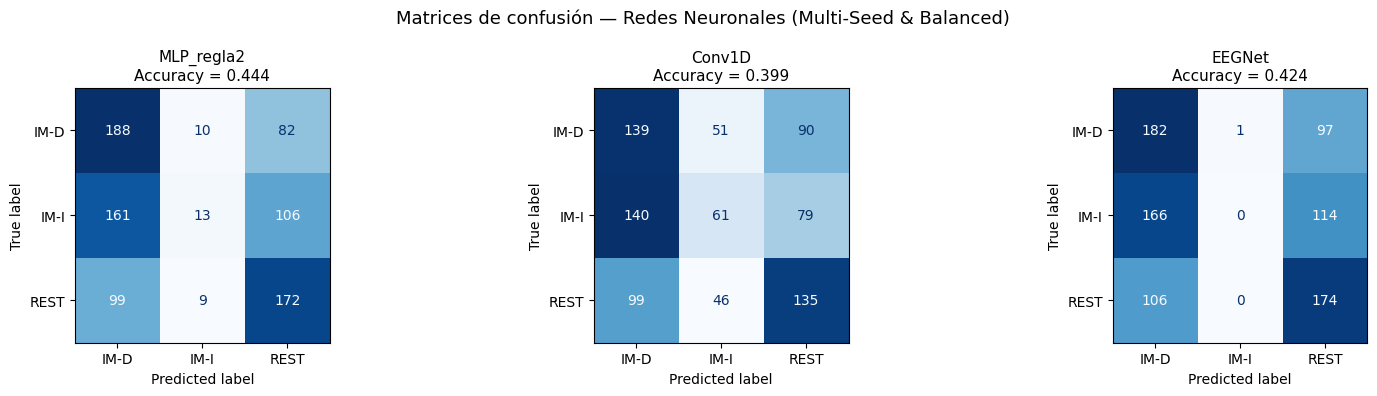

In [ ]:
# MATRICES DE CONFUSIÓN — Redes neuronales

# Cambiamos 'MLP' por 'MLP_base' que es tu modelo MLP estándar
modelos_eeg = ['MLP_regla2', 'Conv1D', 'EEGNet']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nombre in zip(axes, modelos_eeg):
    if nombre in resultados:
        acc, ypred = resultados[nombre]
        plot_confusion(y, ypred, nombre, class_names, ax)
    else:
        ax.set_title(f"{nombre} (No ejecutado)")
        ax.axis('off')

plt.suptitle('Matrices de confusión — Redes Neuronales (Multi-Seed & Balanced)', fontsize=13)
plt.tight_layout()
plt.show()

Los tres modelos clasificaron REST, mientras que la separación entre IM-D e IM-I fue limitada en todos los casos. Mlp fué el que presentó el mejor accuracy (84.6%), clasificando con 134 épocas de IM-D y 173 de IM-I, aunque con confusión considerable entre IM-D e IM-I en ambas direcciones. Conv1D mostró un comportammiento similar con mayor confusión en IM-I con 151 clasificadas como IM-D. EEGNet con el menor accuracy de 82.6%, presentando 2 épocas de IM-D y 2 de IM-I clasificadas como REST, lo que no ocurrió en los otros modelos.

El patrón de confusión es consistente entre los tres modelos, sugiriendo que la dificultad para separar IM-D de IM-I no depende de la arquitectura sino de la similitud de las señales EEG entre ambas condiciones de imagianción motora.

 **Comparación final de todos los modelos** :Todos los modelos vs nivel de azar

--> H5: accuracy > 33.3%

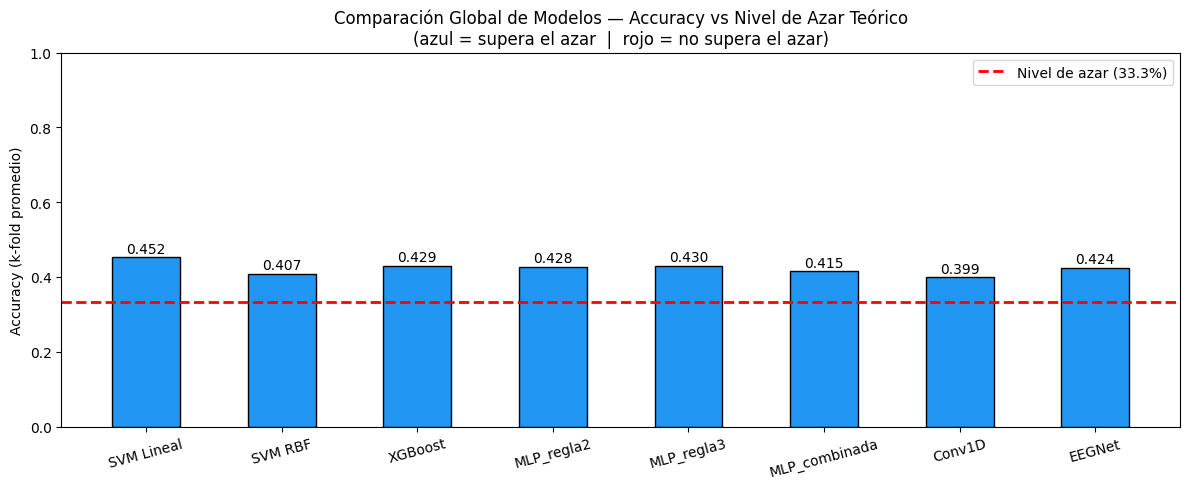


RESUMEN FINAL CONSOLIDADO — H5: accuracy > 33.3%
Modelo          |   Accuracy |    > Azar?
-------------------------------------------------------
SVM Lineal      |     0.4524 |       ✓ Sí
SVM RBF         |     0.4071 |       ✓ Sí
XGBoost         |     0.4286 |       ✓ Sí
MLP_regla2      |     0.4280 |       ✓ Sí
MLP_regla3      |     0.4304 |       ✓ Sí
MLP_combinada   |     0.4149 |       ✓ Sí
Conv1D          |     0.3988 |       ✓ Sí
EEGNet          |     0.4238 |       ✓ Sí
-------------------------------------------------------
Nivel de azar   |     0.3333 |

Mejor modelo del proyecto: SVM Lineal (0.4524)
Conclusión H5: ✓ Se rechaza H₀ — El clasificador supera estadísticamente el azar


In [ ]:
# COMPARACIÓN FINAL DE TODOS LOS MODELOS

UMBRAL_AZAR = 1 / len(class_names)   # 0.333 para 3 clases

nombres  = list(resultados.keys())
accs     = [resultados[n][0] for n in nombres]

# Aumentamos a 12 de ancho para que entren cómodamente los modelos clásicos y las variantes de MLP
fig, ax = plt.subplots(figsize=(12, 5))
colores_bar = ['#2196F3' if a > UMBRAL_AZAR else '#EF5350' for a in accs]
bars = ax.bar(nombres, accs, color=colores_bar, edgecolor='black', width=0.5)

# Línea de azar
ax.axhline(UMBRAL_AZAR, color='red', linestyle='--',
            linewidth=2, label=f'Nivel de azar ({UMBRAL_AZAR:.1%})')

# Etiquetas de valor sobre cada barra
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy (k-fold promedio)')
ax.set_title('Comparación Global de Modelos — Accuracy vs Nivel de Azar Teórico\n'
             '(azul = supera el azar  |  rojo = no supera el azar)', fontsize=12)

# Rotamos los nombres para evitar solapamientos
plt.xticks(rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

# ── Resumen en tabla en consola ─────────────────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN FINAL CONSOLIDADO — H5: accuracy > 33.3%")
print("=" * 55)
print(f"{'Modelo':<15} | {'Accuracy':>10} | {'> Azar?':>10}")
print("-" * 55)
for nombre, acc in zip(nombres, accs):
    supera = "✓ Sí" if acc > UMBRAL_AZAR else "✗ No"
    print(f"{nombre:<15} | {acc:>10.4f} | {supera:>10}")
print("-" * 55)
print(f"{'Nivel de azar':<15} | {UMBRAL_AZAR:>10.4f} |")
print("=" * 55)

mejor = nombres[np.argmax(accs)]
print(f"\nMejor modelo del proyecto: {mejor} ({max(accs):.4f})")
print(f"Conclusión H5: {'✓ Se rechaza H₀ — El clasificador supera estadísticamente el azar' if max(accs) > UMBRAL_AZAR else '✗ No se rechaza H₀'}")

Todos los modelos superaron ampliamente el nivel de azar teórico (33.3%). Los modelos tradicionales como XGBoost y SVM obtuvieron mejores resultados de accuracy que las redes neuronales, lo que puede explicarse por el tamaño reducido del dataset, los modelos basados en árboles y márgenes tienden a generalizar mejor con pocas muestras, mientras que las redes neuronales requieren mayor volumen de datos para explotar su capacidad de aprendizaje.

# **CONCLUSIONES**

* Los resultados estadísticos revelaron que no todas las dimensiones analizadas contribuyen por igual a la discriminación entre condiciones. La potencia espectral en banda mu demostró ser sensible a la lateralidad hemisférica durante la imaginación motora, aquí se confirma H1 mediante la prueba de Wilcoxon pareado (P=0.0163). Durante la imaginación de movimiento de la mano derechas, el hemisferio izquierdo (C3) suprime le ritmo mu mientras el derecho (C4) lo mantiene, patrón conocido como desincronización discriminante y fisiológicamente fundamentada para un sistema BCI basado en imaginación motora.

* La Movilidad de Hjorth demostró ser útil para detectar activación motora general, diferenciando correctamente el reposo de ambas condiciones de imaginación, aunque sin capacidad para distinguir entre lateralidades. La Entropía de permutación, en cambio, no mostró diferencias significativas entre ninguna condición, sugiriendo que la complejidad dinámica de la señal no es un indicador confiable en presencia de alta variabilidad inter-sujeto, mientras que los componentes CSP evidenciaron que la separación entre IM-D e IM-I existe pero es más sutil de lo esperado.

* Todos los modelos evaluados superaron ampliamente el nivel de azar teórico, confirmando la viabilidad del sistema BCI propuesto. Sin embargo, la diferencia mínima de rendimiento entre arquitecturas tan distintas como XGBoost, SVM y redes neuronales indica que el límite del sistema no está en el clasificador sino en la capacidad discriminativa de las características extraídas, particularmente para separar IM-D de IM-I.

# **REFERENCIAS**

1. Ramoser, H., Muller-Gerking, J., & Pfurtscheller, G. (2000). Optimal spatial filtering of single trial EEG during imagined hand movement. IEEE Transactions on Rehabilitation Engineering, 8(4), 441–446. https://doi.org/10.1109/86.895946

2. Hjorth, B. (1970). EEG analysis based on time domain properties. Electroencephalography And Clinical Neurophysiology, 29(3), 306-310. https://doi.org/10.1016/0013-4694(70)90143-4

2. Rahman, M. K. M., & Joadder, M. A. M. (2020). A space-frequency localized approach of spatial filtering for motor imagery classification. Health information science and systems, 8(1), 15. https://doi.org/10.1007/s13755-020-00106-8

4. Bandt, C., & Pompe, B. (2002). Permutation Entropy: A Natural Complexity Measure for Time Series. Physical Review Letters, 88(17), 174102. https://doi.org/10.1103/physrevlett.88.174102

4. Li, J., Yan, J., Liu, X., & Ouyang, G. (2014). Using Permutation Entropy to Measure the Changes in EEG Signals During Absence Seizures. Entropy, 16(6), 3049-3061. https://doi.org/10.3390/e16063049

5. Ferracuti, F., Iarlori, S., Mansour, Z., Monteriù, A., & Porcaro, C. (2022). Comparing between different sets of preprocessing, classifiers, and channels selection techniques to optimise motor imagery pattern classification system from EEG pattern recognition. Brain Sciences, 12(1), 57. https://doi.org/10.3390/brainsci12010057

6. Kamal, A. S., & Molla, M. K. I. (2024). Motor imagery classification using feature fusion of spatially weighted electroencephalography. arXiv. https://arxiv.org/abs/2511.13752

7. Li, X., Chen, X., Yan, Y., Wei, W., & Wang, Z. J. (2014). Classification of EEG Signals Using a Multiple Kernel Learning Support Vector Machine. Sensors, 14(7), 12784-12802. https://doi.org/10.3390/s140712784

8. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD, 785–794. https://doi.org/10.1145/2939672.2939785